# Data Girls Finance - Credit Score Classification Project

## Contexto do Projeto

Bem-vindo ao projeto final do Bootcamp [RE]Start – Trilha de Cientista de Dados!

Este projeto simula um cenário real de negócio na **Data Girls Finance**, uma fintech fictícia que busca tornar seu processo de análise de crédito mais eficiente, escalável e orientado por dados.

## Objetivo

Construir um modelo preditivo capaz de classificar o score de crédito de clientes com base em:
- Informações financeiras
- Histórico de pagamentos
- Perfil de crédito
- Comportamento financeiro

## Etapas do Projeto

### 1. Leitura e Exploração Inicial dos Dados
- Carregamento do dataset
- Análise das dimensões e tipos de dados
- Identificação de valores ausentes
- Estatísticas descritivas iniciais

### 2. Limpeza e Preparação dos Dados
- Tratamento de valores ausentes
- Tratamento de outliers
- Conversão de tipos de dados
- Codificação de variáveis categóricas

### 3. Análise Exploratória (EDA)
- Análise univariada
- Análise bivariada
- Análise de correlações
- Visualizações e insights

### 4. Modelagem Preditiva
- Divisão treino/teste
- Treinamento de pelo menos 2 modelos supervisionados
- Tuning de hiperparâmetros

### 5. Avaliação dos Modelos
- Comparação de modelos
- Métricas de classificação
- Análise de erros (falsos positivos/negativos)
- Impacto para o negócio
- Importância das variáveis

### 6. Relatório Final
- Documentação completa do pipeline
- Storytelling do projeto
- Principais achados e insights
- Recomendações práticas

Projeto desenvolvido como parte do Bootcamp [RE]Start – Trilha de Cientista de Dados

Este é um projeto educacional para fins de aprendizado.

---------

# 1. Leitura e Exploração Inicial dos Dados

Para essa primeira etapa, vamos carregar o dataset e verificar suas dimensões e tipos de dados, além de identificar valores ausentes e realizar estatísticas descritivas iniciais. Nessa etapa não visamos tratar os dados ainda, apenas entender a "anatomia" do nosso dataset.

In [1]:
# Importando as bibliotecas

# Operações matemáticas
import numpy as np 

# Manipulação de dados
import pandas as pd

# Plotar gráficos
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

Vamos importar dois csv: treino e teste. Neste caso, o dataset já veio dividido e isso facilita muito na hora de treinar, pois evita o famoso data leakage.

In [2]:
# Carregando o dataset de treino e criando uma cópia para backup
df_treino_original = pd.read_csv('train.csv')
df_treino = df_treino_original.copy()
df_treino

/var/folders/wl/hvly4qw17xv00wzyh8rcmmcm0000gn/T/ipykernel_76745/723631221.py:2: DtypeWarning: Columns (0: Monthly_Balance) have mixed types. Specify dtype option on import or set low_memory=False.
  df_treino_original = pd.read_csv('train.csv')


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0x25fe9,CUS_0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor
99996,0x25fea,CUS_0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor
99997,0x25feb,CUS_0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor
99998,0x25fec,CUS_0x942c,July,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,Good,502.38,33.638208,31 Years and 9 Months,No,35.104023,251.67258219721603,Low_spent_Large_value_payments,319.164979,Standard


In [3]:
# Carregando o dataset de teste e criando uma cópia para backup
df_teste_original = pd.read_csv('test.csv')
df_teste = df_teste_original.copy()
df_teste

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,0x160a,CUS_0xd40,September,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.64268203272135,Low_spent_Small_value_payments,186.26670208571772
1,0x160b,CUS_0xd40,October,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.465380264657146,High_spent_Medium_value_payments,361.44400385378196
2,0x160c,CUS_0xd40,November,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.811894,NaN,No,49.574949,148.23393788500925,Low_spent_Medium_value_payments,264.67544623342997
3,0x160d,CUS_0xd40,December,Aaron Maashoh,24_,821-00-0265,Scientist,19114.12,NaN,3,...,4.0,Good,809.98,32.430559,23 Years and 0 Months,No,49.574949,39.08251089460281,High_spent_Medium_value_payments,343.82687322383634
4,0x1616,CUS_0x21b1,September,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2,...,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.684018417945296,High_spent_Large_value_payments,485.2984336755923
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0x25fe5,CUS_0x8600,December,Sarah McBridec,4975,031-35-0942,Architect,20002.88,1929.906667,10,...,12.0,_,3571.7,34.780553,NaN,Yes,60.964772,146.48632477751087,Low_spent_Small_value_payments,275.53956951573343
49996,0x25fee,CUS_0x942c,September,Nicks,25,078-73-5990,Mechanic,39628.99,NaN,4,...,7.0,Good,502.38,27.758522,31 Years and 11 Months,NM,35.104023,181.44299902757518,Low_spent_Small_value_payments,409.39456169535066
49997,0x25fef,CUS_0x942c,October,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,7.0,Good,502.38,36.858542,32 Years and 0 Months,No,35.104023,__10000__,Low_spent_Large_value_payments,349.7263321025098
49998,0x25ff0,CUS_0x942c,November,Nicks,25,078-73-5990,Mechanic,39628.99,NaN,4,...,7.0,Good,502.38,39.139840,32 Years and 1 Months,No,35.104023,97.59857973344877,High_spent_Small_value_payments,463.23898098947717


Aqui, vamos começar a entender a estrutura dos dataframes.

In [4]:
df_treino.shape, df_teste.shape

((100000, 28), (50000, 27))

In [5]:
display(
    df_treino.info(), 
    print(), 
    df_teste.info()
)

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  str    
 1   Customer_ID               100000 non-null  str    
 2   Month                     100000 non-null  str    
 3   Name                      90015 non-null   str    
 4   Age                       100000 non-null  str    
 5   SSN                       100000 non-null  str    
 6   Occupation                100000 non-null  str    
 7   Annual_Income             100000 non-null  str    
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  str    
 13  Type_of_Loan              88592 non-null   str    
 14  

None

None

None

## Estatística Descritiva dos dataframes

**Highlights:**

- Salário mensal líquido médio (Montly_Inhand_Salary) = 4.194,00
- Desvio padrão do salário mensal (std) = 3.183,00 (provavelmente há algum outlier)
- A média de contas bancárias é de 17 por pessoa (também pode ser um outlier)
- Geralmente, as pessoas atrasam seu pagamento em 21 dias (média de Delay_from_due_date)
- Temos que tratar o dado Age para que seja um int, e assim podermos fazer a média de idade. Atualmente está como string.
- Mesma coisa para Annual_Income e Outstanding_Debt, que estão como string.

Começando pelo dataframe de treino, vamos analisar primeiro as colunas numéricas. Depois, incluiremos as colunas com texto.

In [6]:
df_treino.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


In [7]:
df_treino.describe(include='object')

/var/folders/wl/hvly4qw17xv00wzyh8rcmmcm0000gn/T/ipykernel_76745/135863002.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_treino.describe(include='object')


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Num_of_Loan,Type_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000,100000,100000,90015,100000,100000,100000,100000,100000,88592,92998,100000,100000,100000,90970,100000,95521,100000,98800,100000
unique,100000,12500,8,10139,1788,12501,16,18940,434,6260,749,4384,4,13178,404,3,91049,7,98792,3
top,0x1602,CUS_0xd40,January,Langep,38,#F%$D@*&8,_______,17273.83,3,Not Specified,19,_,Standard,1360.45,15 Years and 11 Months,Yes,__10000__,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
freq,1,8,12500,44,2833,5572,7062,16,14386,1408,5327,2091,36479,24,446,52326,4305,25513,9,53174


Agora, o mesmo para dataframe de teste:

In [8]:
df_teste.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,42502.000000,50000.000000,50000.000000,50000.000000,50000.000000,48965.000000,50000.000000,50000.000000
mean,4182.004291,16.838260,22.921480,68.772640,21.052640,30.080200,32.279581,1491.304305
std,3174.109304,116.396848,129.314804,451.602363,14.860397,196.984121,5.106238,8595.647887
min,303.645417,-1.000000,0.000000,1.000000,-5.000000,0.000000,20.509652,0.000000
25%,1625.188333,3.000000,4.000000,8.000000,10.000000,4.000000,28.061040,32.222388
50%,3086.305000,6.000000,5.000000,13.000000,18.000000,7.000000,32.280390,74.733349
75%,5934.189094,7.000000,7.000000,20.000000,28.000000,10.000000,36.468591,176.157491
max,15204.633333,1798.000000,1499.000000,5799.000000,67.000000,2593.000000,48.540663,82398.000000


In [9]:
df_teste.describe(include='object')

/var/folders/wl/hvly4qw17xv00wzyh8rcmmcm0000gn/T/ipykernel_76745/2466481699.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_teste.describe(include='object')


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Num_of_Loan,Type_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
count,50000,50000,50000,44985,50000,50000,50000,50000,50000,44296,46502,50000,50000,50000,45530,50000,47729,50000,49438
unique,50000,12500,4,10139,976,12501,16,16121,263,6260,443,3927,4,12685,399,3,45450,7,49433
top,0x160a,CUS_0xd40,September,Stevex,39,#F%$D@*&8,_______,9141.63,2,Not Specified,19,_,Standard,1151.7,20 Years and 1 Months,Yes,__10000__,Low_spent_Small_value_payments,__-333333333333333333333333333__
freq,1,4,12500,22,1493,2828,3438,8,7173,704,2622,1059,18379,12,254,26158,2175,12694,6


Agora, vamos seguir apenas com o dataset de treino, pois ele é o mais importante para o modelo. Fazemos apenas uma estatística descritiva básica para o dataset de teste, apenas para checar se ele não é tão destoante com o de treino. Ao analisá-lo, pude perceber que a única diferença relevante é o fato dele não possuir a coluna de Credit_Score, que é o que queremos prever, no fim das contas.

-----


# 2. Limpeza e Preparação dos Dados

Vamos utilizar bibliotecas como matplotlib e seaborn para visualizar os dados e entender melhor as relações entre as variáveis, identificar outliers, entre outros. Assim, poderemos realizar a limpeza e tratamento adequado dos dados.

### Tratando tipos de colunas

Neste dataset, a coluna de Age, Outstanding_Dept e Annual_Income estão como string. Vamos converter para int e float, para que possamos fazer cálculos com elas.

In [10]:
# Coluna Age

df_treino[df_treino['Age'].apply(lambda x: pd.to_numeric(x, errors='coerce')).isna()]['Age'].unique()

<StringArray>
[  '28_',   '34_',   '30_',   '24_',   '33_',   '35_',   '31_',   '40_',
   '37_',   '54_',
 ...
 '7122_', '4913_', '5697_', '3843_', '4445_', '6921_',  '780_', '1070_',
 '5798_', '4808_']
Length: 127, dtype: str

Descobrimos que alguns valores da coluna Age possuem underscore. Para isso, vamos remover o underscore desses valores e depois converter a coluna para int.

In [11]:
df_treino['Age'] = df_treino['Age'].str.replace('_', '', regex=False)
df_treino['Age'] = df_treino['Age'].astype(int)

In [12]:
df_treino['Age'].describe()

count    100000.000000
mean        110.649700
std         686.244717
min        -500.000000
25%          24.000000
50%          33.000000
75%          42.000000
max        8698.000000
Name: Age, dtype: float64

Boxplot da coluna de idade:

<Axes: >

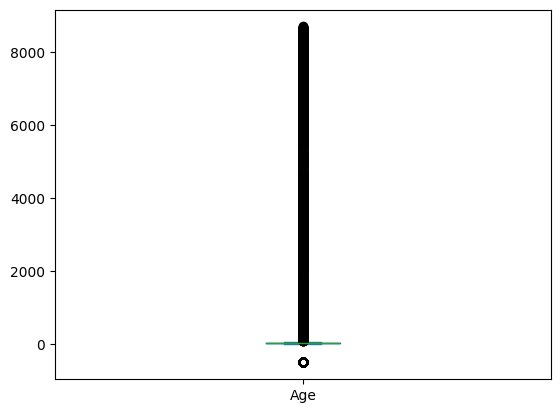

In [13]:
df_treino['Age'].plot.box()

Agora, as colunas Outstanding_Dept e Annual_Income para float.

In [14]:
df_treino['Outstanding_Debt'] = df_treino['Outstanding_Debt'].str.replace('_', '', regex=False)

df_treino['Outstanding_Debt'] = df_treino['Outstanding_Debt'].astype(float)

<Axes: >

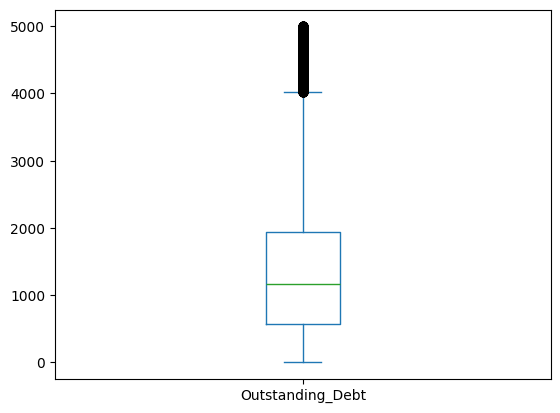

In [15]:
df_treino['Outstanding_Debt'].describe()

df_treino['Outstanding_Debt'].plot.box()

In [16]:
df_treino[df_treino['Annual_Income'].apply(lambda x: pd.to_numeric(x, errors='coerce')).isna()]['Annual_Income'].unique()

<StringArray>
[ '34847.84_',  '30689.89_',  '35547.71_',  '34081.38_', '114838.41_',
  '88640.24_',  '54392.16_',  '8701.545_',  '25546.26_',  '92047.08_',
 ...
  '39977.21_',  '10692.16_',  '64511.34_',  '41329.56_',  '20059.98_',
 '139664.96_',  '38321.39_',  '16680.35_',   '37188.1_',  '39628.99_']
Length: 5503, dtype: str

In [17]:
df_treino['Annual_Income'] = df_treino['Annual_Income'].str.replace('_', '', regex=False)

df_treino['Annual_Income'] = df_treino['Annual_Income'].astype(float)

In [18]:
df_treino['Annual_Income'].describe()

count    1.000000e+05
mean     1.764157e+05
std      1.429618e+06
min      7.005930e+03
25%      1.945750e+04
50%      3.757861e+04
75%      7.279092e+04
max      2.419806e+07
Name: Annual_Income, dtype: float64

O describe aparece dessa forma pois os valores em float do Annual_Income são extremamente discrepantes e altos, por exemplo, renda anual de 24 milhões. Nesse sentido, apesar de ser difícil, é perfeitamente possível que esse cenário ocorra quando falamos de Credit Score e finanças com um grupo variado de pessoas. Por isso, não irei tratar esses outliers nesse caso específico.

### Lidando com outliers

<Axes: >

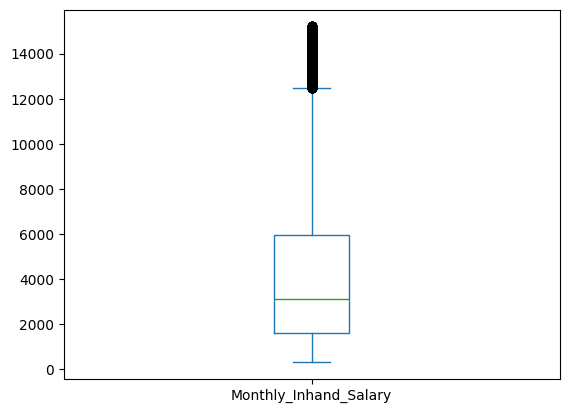

In [19]:
df_treino['Monthly_Inhand_Salary'].plot.box()

<Axes: >

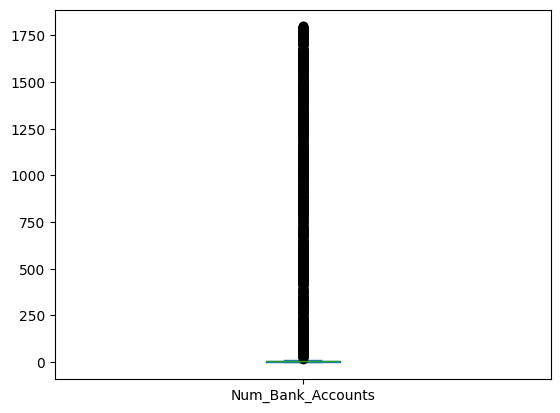

In [20]:
df_treino['Num_Bank_Accounts'].plot.box()

Identificamos duas categorias com outliers. A primeira, Monthly_Inhand_Salary, não pode ser "consertada" porque é possível que alguém ganhe este valor discrepante e é importante que mantenhamos essa informação. O Num_Bank_Accounts já é importante que tratemos, pois é altamente improvável que alguém tenha 1700 contas no banco. 

Para isso, vou fazer uma função que identifique o número de outliers em cada coluna do dataframe, para que possamos decidir se devemos ou não tratá-la. Vou usar o método quantile para calcular os quartis e o IQR, e depois contar quantos valores estão fora dos limites definidos por 1.5 vezes o IQR.

In [21]:
for coluna in df_treino.select_dtypes(include='number').columns:
    Q1 = df_treino[coluna].quantile(0.25)
    Q3 = df_treino[coluna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    n_outliers = ((df_treino[coluna] < limite_inferior) |
                  (df_treino[coluna] > limite_superior)).sum()

    print(f'{coluna}: {n_outliers} outliers')

Age: 2781 outliers
Annual_Income: 2783 outliers
Monthly_Inhand_Salary: 1683 outliers
Num_Bank_Accounts: 1315 outliers
Num_Credit_Card: 2271 outliers
Interest_Rate: 2034 outliers
Delay_from_due_date: 4002 outliers
Num_Credit_Inquiries: 1650 outliers
Outstanding_Debt: 5272 outliers
Credit_Utilization_Ratio: 4 outliers
Total_EMI_per_month: 6795 outliers


Para tratar esses outliers, vamos usar a técnica de winsorização: tratar outliers sem removê-los e sem substituir todos eles pela média ou mediana, "cortando" esses valores baseados nos limites do IQR. É recomendado quando temos de 5% a 10% de outliers. Vou aproveitar para tratar a coluna de "Age" também.

In [22]:
colunas_trataveis = ['Num_Bank_Accounts', 'Num_Credit_Card', 'Age']

for coluna in colunas_trataveis:
    Q1 = df_treino[coluna].quantile(0.25)
    Q3 = df_treino[coluna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    df_treino[coluna] = df_treino[coluna].clip(
        lower=limite_inferior,
        upper=limite_superior
    )

Visualizando nossas colunas:

Antes: mediana de 17 e desvio padrão de 116 para Num_Bank_Accounts, ou seja, a média de contas no banco era de 17 por pessoa.
Agora: a média de contas no banco é de 5 por pessoa, com desvio padrão de 2.

In [23]:
df_treino[colunas_trataveis].describe()

,Num_Bank_Accounts,Num_Credit_Card,Age
count,100000.000000,100000.000000,100000.000000
mean,5.467990,5.668825,33.674350
std,2.719465,2.229002,12.183791
min,-1.000000,0.000000,-3.000000
25%,3.000000,4.000000,24.000000
50%,6.000000,5.000000,33.000000
75%,7.000000,7.000000,42.000000
max,13.000000,11.500000,69.000000


Novo boxplot para o Num_Bank_Accounts:

<Axes: >

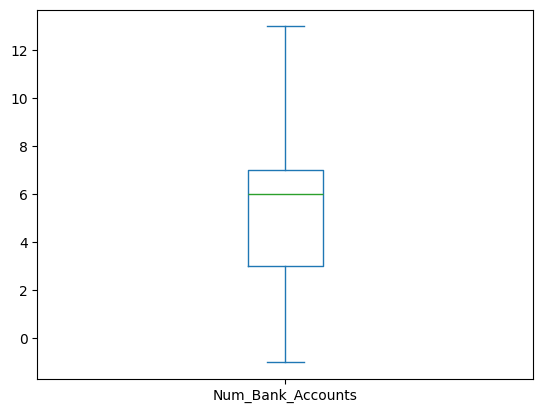

In [24]:
df_treino['Num_Bank_Accounts'].plot.box()

Novo boxplot para Age:

<Axes: >

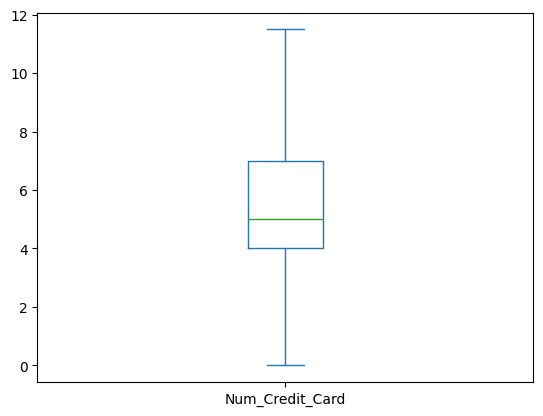

In [25]:
df_treino['Num_Credit_Card'].plot.box()


<Axes: >

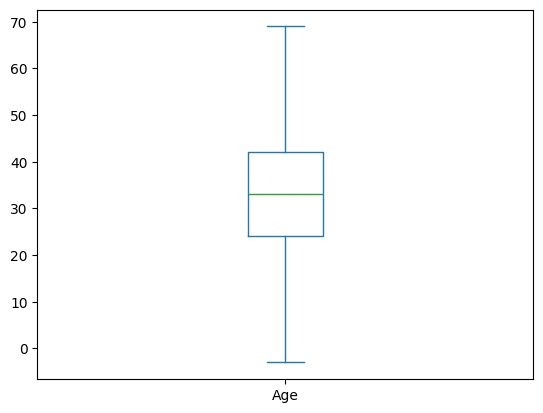

In [26]:
df_treino['Age'].plot.box()

Arrumando a coluna de Credit History Age de string para float, assim podemos fazer gráficos e histogramas:

In [27]:
df_treino['Credit_History_Age'] = (
    df_treino['Credit_History_Age']
    .str.extract(r'(\d+)\s+Years?\s+and\s+(\d+)\s+Months?')
    .astype(float)
    .pipe(lambda x: x[0] * 12 + x[1])
)

df_treino['Credit_History_Age_Years'] = (
    df_treino['Credit_History_Age'] / 12
)

### Lidando com dados duplicados e nulos



Verificando nulos no dataset

In [28]:
df_treino.isnull().sum()

ID                              0
Customer_ID                     0
Month                           0
Name                         9985
Age                             0
SSN                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary       15002
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                11408
Delay_from_due_date             0
Num_of_Delayed_Payment       7002
Changed_Credit_Limit            0
Num_Credit_Inquiries         1965
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age           9030
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      4479
Payment_Behaviour               0
Monthly_Balance              1200
Credit_Score                    0
Credit_History_Age_Years     9030
dtype: int64

Apenas as colunas com nulos:

In [29]:
df_treino.isnull().sum()[df_treino.isnull().sum() > 0]

Name                         9985
Monthly_Inhand_Salary       15002
Type_of_Loan                11408
Num_of_Delayed_Payment       7002
Num_Credit_Inquiries         1965
Credit_History_Age           9030
Amount_invested_monthly      4479
Monthly_Balance              1200
Credit_History_Age_Years     9030
dtype: int64

Verificando os nulos escondidos para cada coluna de classificação:

In [30]:
df_treino['Occupation'].value_counts()

Occupation
_______          7062
Lawyer           6575
Architect        6355
Engineer         6350
Scientist        6299
Mechanic         6291
Accountant       6271
Developer        6235
Media_Manager    6232
Teacher          6215
Entrepreneur     6174
Doctor           6087
Journalist       6085
Manager          5973
Musician         5911
Writer           5885
Name: count, dtype: int64

In [31]:
df_treino['Credit_Mix'].value_counts()

Credit_Mix
Standard    36479
Good        24337
_           20195
Bad         18989
Name: count, dtype: int64

In [32]:
df_treino['Type_of_Loan'].value_counts()

Type_of_Loan
Not Specified                                                                                        1408
Credit-Builder Loan                                                                                  1280
Personal Loan                                                                                        1272
Debt Consolidation Loan                                                                              1264
Student Loan                                                                                         1240
                                                                                                     ... 
Auto Loan, Payday Loan, Auto Loan, Student Loan, Student Loan, Student Loan, and Home Equity Loan       8
Home Equity Loan, Payday Loan, Not Specified, and Personal Loan                                         8
Home Equity Loan, Auto Loan, Auto Loan, and Auto Loan                                                   8
Payday Loan, Student Loan, Mortga

In [33]:
df_treino['Payment_of_Min_Amount'].value_counts()

Payment_of_Min_Amount
Yes    52326
No     35667
NM     12007
Name: count, dtype: int64

Transformando os valores nulos escondidos em NaN, para substituir pela mediana e moda.

Observação: escolhi não tratar os valores de Payment_of_Min_Amount, pois pode enviesar o modelo.

In [34]:
df_treino = df_treino.replace(
    ['_______', '_', '__',],
    np.nan
)

Separando entre numéricas e categóricas:

In [35]:
colunas_numericas = df_treino.select_dtypes(include='number').columns
colunas_categoricas = df_treino.select_dtypes(include='object').columns

/var/folders/wl/hvly4qw17xv00wzyh8rcmmcm0000gn/T/ipykernel_76745/1954691440.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_categoricas = df_treino.select_dtypes(include='object').columns


Preenchendo os valores vazios com a mediana das colunas numéricas:

In [36]:
for col in colunas_numericas:
    mediana = df_treino[col].median()

    df_treino[col] = df_treino[col].fillna(mediana)

Preenchendo os valores vazios com a moda nas colunas categóricas:

In [37]:
for col in colunas_categoricas:
    moda = df_treino[col].mode()[0]

    df_treino[col] = df_treino[col].fillna(moda)

Verificando se ainda há nulos:

In [38]:
df_treino.isnull().sum()

ID                          0
Customer_ID                 0
Month                       0
Name                        0
Age                         0
SSN                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
Credit_History_Age_Years    0
dtype: int64

Verificando os duplicados no dataset

In [39]:
df_treino.duplicated().sum()

np.int64(0)

Procurando e limpando os valores sujos "escondidos"

In [40]:
import re

# procura qualquer caractere que não seja: letras, números, espaço, vírgula, ponto, _, -

for coluna in df_treino.select_dtypes(include='object').columns:
    valores = df_treino[coluna].dropna().astype(str)

    suspeitos = valores[
        valores.str.contains(r'[^a-zA-Z0-9\s,._-]', regex=True)
    ].unique()

    if len(suspeitos) > 0:
        print(f'\n{coluna}:')
        print(suspeitos)

/var/folders/wl/hvly4qw17xv00wzyh8rcmmcm0000gn/T/ipykernel_76745/868177391.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for coluna in df_treino.select_dtypes(include='object').columns:



Name:
<StringArray>
[  '"John ODonnell"p',   '"John ODonnell"f',          '"Manuelap',
           '"Eileene',   '"John ODonnell"s',         'ODonnell"i',
           '"Eileenf',  '"Rosalba OBrien"p',             '"Johnc',
   '"John ODonnell"q',           'OBrien"q',   '"Eileen OGrady"s',
           '"Martiny',         'ODonnell"p',          '"Michaelg',
         'ODonnell"m',           'OGrady"g',   '"John ODonnell"a',
             '"Johnb',   '"Eileen OGrady"t',             '"Johne',
             '"Johnn',           'OBoyle"f',    'SaPinto" Tommyl',
         'ODonnell"s',             '"Johnd',             '"Johnr',
          '"Michaels',           'OGrady"k',           'OGrady"z',
         'ODonnell"r',             '"Johnp',         'ODonnell"y',
 '"John OCallaghan"g',             '"Johnw',   '"John ODonnell"e',
             '"Johnz',             '"Johnk',   '"John ODonnell"t',
   '"Eileen OGrady"v',   '"John ODonnell"n',         'ODonnell"e',
           'OBrien"u',           '"Eileen

Temos 0 valores duplicados, então podemos seguir com a análise exploratória.

Nosso dataset:

In [41]:
df_treino.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Credit_History_Age_Years
count,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,33.674350,1.764157e+05,4029.084964,5.467990,5.668825,72.466040,21.068780,27.326780,1426.220376,32.285173,220.997160,1403.118217,18.416430
std,12.183791,1.429618e+06,2961.363540,2.719465,2.229002,466.422621,14.860104,191.293766,1155.129026,5.116875,95.133546,8306.041270,7.927795
min,-3.000000,7.005930e+03,303.645417,-1.000000,0.000000,1.000000,-5.000000,0.000000,0.230000,20.000000,1.000000,0.000000,0.083333
25%,24.000000,1.945750e+04,1792.084167,3.000000,4.000000,8.000000,10.000000,3.000000,566.072500,28.052567,154.000000,30.306660,12.833333
50%,33.000000,3.757861e+04,3093.745000,6.000000,5.000000,13.000000,18.000000,6.000000,1166.155000,32.305784,219.000000,69.249473,18.250000
75%,42.000000,7.279092e+04,5371.525000,7.000000,7.000000,20.000000,28.000000,9.000000,1945.962500,36.496663,292.000000,161.224249,24.333333
max,69.000000,2.419806e+07,15204.633333,13.000000,11.500000,5797.000000,67.000000,2597.000000,4998.070000,50.000000,404.000000,82331.000000,33.666667


### Limpando também o dataset de teste

É importante que apliquemos a limpeza também no teste, pois em um datalake normal, os dados não vêm dividos em treino e teste. 

In [42]:
# ============================================================
# LIMPEZA E PREPARAÇÃO DO DATASET DE TESTE
# ============================================================

# 1. Transformar nulos escondidos em NaN
df_teste = df_teste.replace(
    ['_______', '_', '__'],
    np.nan
)

# 2. Corrigir colunas com underscore / strings numéricas
df_teste['Age'] = df_teste['Age'].astype(str).str.replace('_', '', regex=False)
df_teste['Age'] = pd.to_numeric(df_teste['Age'], errors='coerce')

df_teste['Outstanding_Debt'] = df_teste['Outstanding_Debt'].astype(str).str.replace('_', '', regex=False)
df_teste['Outstanding_Debt'] = pd.to_numeric(df_teste['Outstanding_Debt'], errors='coerce')

df_teste['Annual_Income'] = df_teste['Annual_Income'].astype(str).str.replace('_', '', regex=False)
df_teste['Annual_Income'] = pd.to_numeric(df_teste['Annual_Income'], errors='coerce')

# 3. Corrigir outras colunas sujas
colunas_numericas_sujas = [
    'Num_of_Loan',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Monthly_Balance',
    'Amount_invested_monthly',
    'Monthly_Inhand_Salary',
    'Num_Credit_Inquiries'
]

for col in colunas_numericas_sujas:
    if col in df_teste.columns:
        df_teste[col] = df_teste[col].astype(str).str.replace('_', '', regex=False)
        df_teste[col] = pd.to_numeric(df_teste[col], errors='coerce')

# 4. Arrumando Credit_History_Age
df_teste['Credit_History_Age'] = (
    df_teste['Credit_History_Age']
    .astype(str)
    .str.extract(r'(\d+)\s+Years?\s+and\s+(\d+)\s+Months?')
    .astype(float)
    .pipe(lambda x: x[0] * 12 + x[1])
)

df_teste['Credit_History_Age_Years'] = df_teste['Credit_History_Age'] / 12

# 5. Lidando com outliers
colunas_trataveis = ['Num_Bank_Accounts', 'Num_Credit_Card', 'Age']

for coluna in colunas_trataveis:
    Q1 = df_teste[coluna].quantile(0.25)
    Q3 = df_teste[coluna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    df_teste[coluna] = df_teste[coluna].clip(
        lower=limite_inferior,
        upper=limite_superior
    )

# 6. Separar colunas numéricas e categóricas
colunas_numericas = df_teste.select_dtypes(include='number').columns
colunas_categoricas = df_teste.select_dtypes(include=['object', 'string']).columns

# 7. Preencher nulos com mediana nas numéricas
for col in colunas_numericas:
    mediana = df_teste[col].median()
    df_teste[col] = df_teste[col].fillna(mediana)

# 8. Preencher nulos com moda nas categóricas
for col in colunas_categoricas:
    if df_teste[col].mode().shape[0] > 0:
        moda = df_teste[col].mode()[0]
        df_teste[col] = df_teste[col].fillna(moda)

# 9. Conferir nulos restantes
df_teste.isnull().sum()[df_teste.isnull().sum() > 0]

Series([], dtype: int64)

In [43]:
df_teste.isnull().sum().sort_values(ascending=False).head(20)

ID                          0
Customer_ID                 0
Monthly_Balance             0
Payment_Behaviour           0
Amount_invested_monthly     0
Total_EMI_per_month         0
Payment_of_Min_Amount       0
Credit_History_Age          0
Credit_Utilization_Ratio    0
Outstanding_Debt            0
Credit_Mix                  0
Num_Credit_Inquiries        0
Changed_Credit_Limit        0
Num_of_Delayed_Payment      0
Delay_from_due_date         0
Type_of_Loan                0
Num_of_Loan                 0
Interest_Rate               0
Num_Credit_Card             0
Num_Bank_Accounts           0
dtype: int64

------

# 3. Análise Exploratória (EDA)

### Análise da variável target: Credit Score.

**Highlights:**


A minoria dos clientes possui um bom credit score. A maioria possui credit score médio, enquanto o ruim encontra-se no meio termo. A distribuição não é tão ruim, temos a oportunidade de transformar de Standard para Good, em vez de começar diretamente com o Poor, o que seria o pior cenário.

A distribuição de credit score por ocupação e por idade também é bastante homogênea, mas vemos algo curioso: a maior parte dos clientes que possuem credit score bons são de idade levemente mais avançada dos que possuem credit score standard ou ruim.

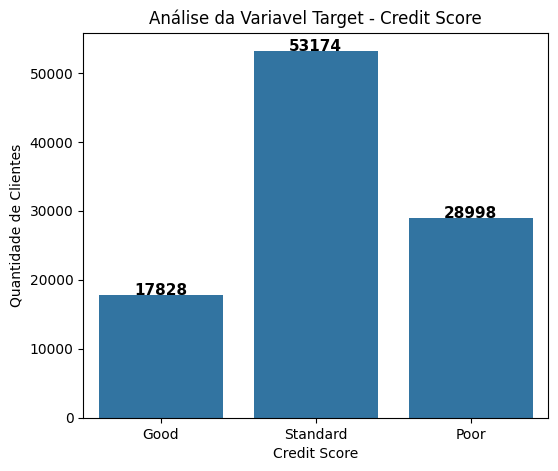

Credit_Score
Good        17.828
Poor        28.998
Standard    53.174
Name: proportion, dtype: float64


In [44]:
plt.figure(figsize=(6,5))
ax = sns.countplot(x='Credit_Score', data=df_treino)
plt.title('Análise da Variavel Target - Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Quantidade de Clientes')

# Configurações visuais do gráfico
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2.,p.get_height()+5),ha='center',va='baseline',fontsize=11, fontweight='bold')
plt.show()

print(df_treino['Credit_Score'].value_counts(normalize=True).sort_index(ascending=True)*100)

### Credit Score por Ocupação

A categoria Lawyer ficou mais avantajada por conta do tratamento dos dados. Ao tratar dados faltantes, completamos com a moda, que possui Lawyer como valor.

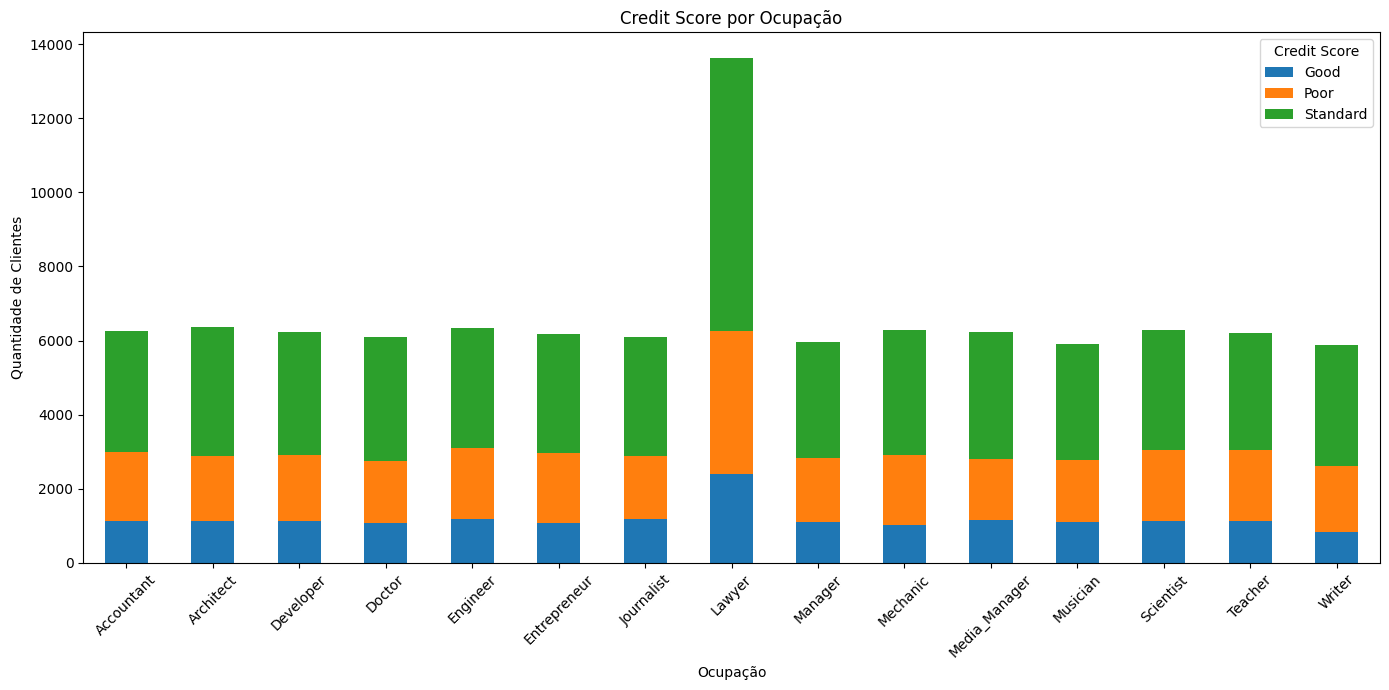

In [45]:
tabela = pd.crosstab(
    df_treino['Occupation'],
    df_treino['Credit_Score']
)

tabela.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7)
)

plt.title('Credit Score por Ocupação')
plt.xlabel('Ocupação')
plt.ylabel('Quantidade de Clientes')
plt.xticks(rotation=45)
plt.legend(title='Credit Score')
plt.tight_layout()
plt.show()

### Credit Score por Idade

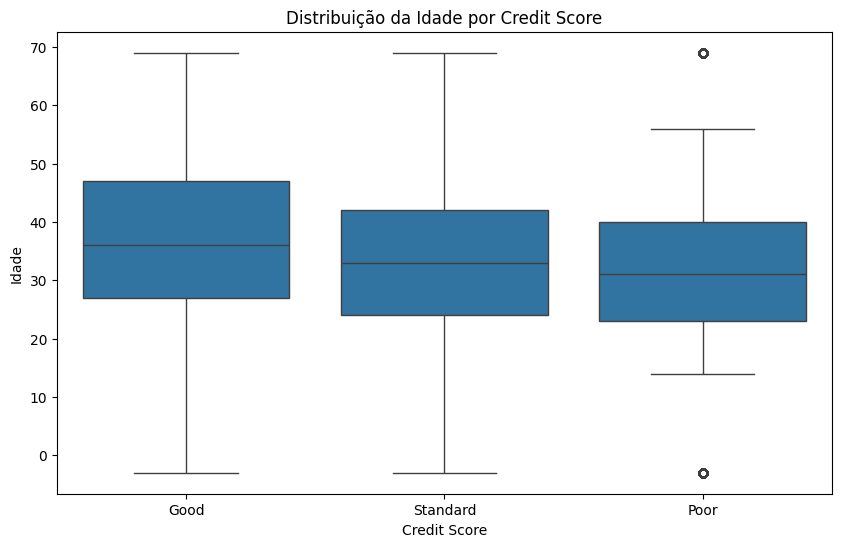

In [46]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_treino,
    x='Credit_Score',
    y='Age'
)

plt.title('Distribuição da Idade por Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Idade')
plt.show()

### Salário Mensal por Ocupação

Distribuição homogênea de salários entre ocupações. Temos um maior número de outliers na ocupação Lawyer, mas nada significativo para análise.

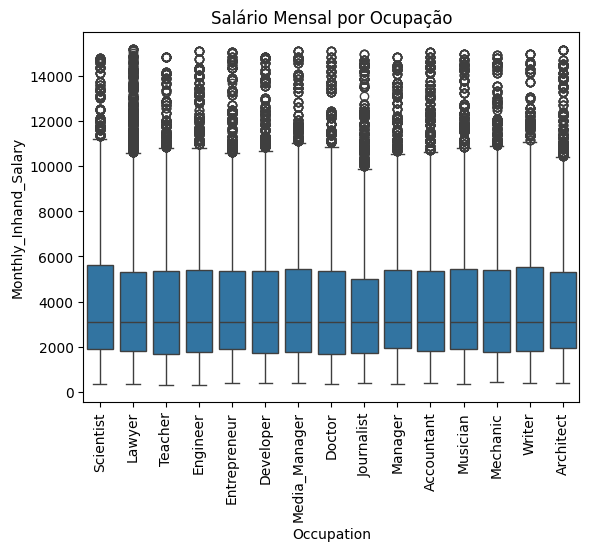

In [47]:
sns.boxplot(data=df_treino, x='Occupation', y='Monthly_Inhand_Salary')
plt.title('Salário Mensal por Ocupação')
plt.xticks(rotation=90)
plt.show()

### Salário Mensal por Idade

Podemos concluir que a maior parte da renda ocorre com idades entre 20 e 40 anos, com valores entre 2 a 4 mil, em média.

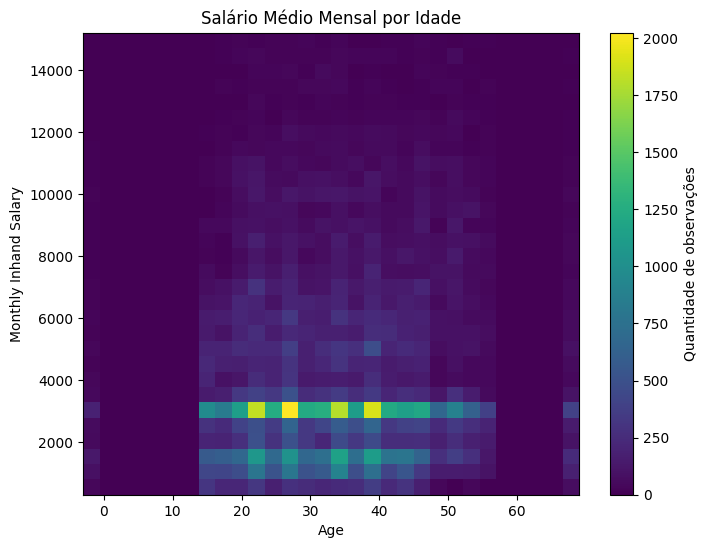

In [48]:
plt.figure(figsize=(8,6))
plt.hist2d(
    df_treino['Age'],
    df_treino['Monthly_Inhand_Salary'],
    bins=30
)
plt.xlabel('Age')
plt.ylabel('Monthly Inhand Salary')
plt.title('Salário Médio Mensal por Idade')
plt.colorbar(label='Quantidade de observações')
plt.show()

### Salário Médio por Idade

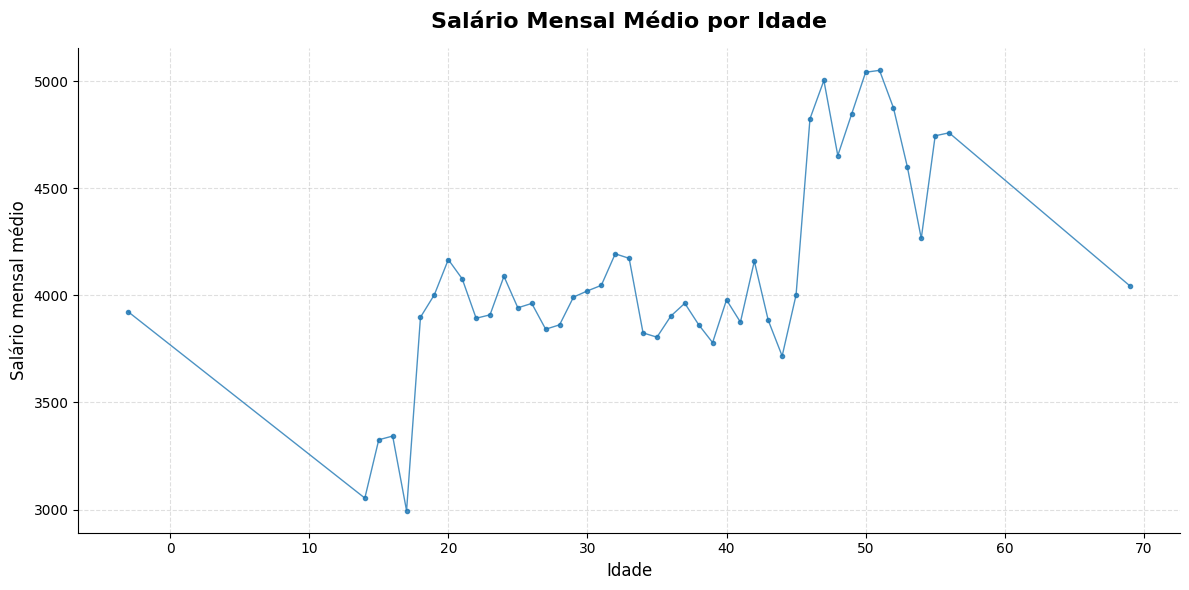

In [49]:
salario_por_idade = (
    df_treino
    .groupby('Age')['Monthly_Inhand_Salary']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    salario_por_idade['Age'],
    salario_por_idade['Monthly_Inhand_Salary'],
    marker='o',
    linewidth=1,
    markersize=3,
    alpha=0.8
)

plt.title(
    'Salário Mensal Médio por Idade',
    fontsize=16,
    fontweight='bold',
    pad=15
)
plt.xlabel('Idade', fontsize=12)
plt.ylabel('Salário mensal médio', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.4)

# Remove as bordas de cima e da direita
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Histogramas do Uso de Crédito

Os gráficos abaixo demonstram que a maioria dos clientes ganham, em média, 3 mil. A taxa de uso de crédito fica entre 20% a 45%, demonstrando baixa a média aderência ao uso. 

A diferença entre a data de vencimento e a data de pagamento também demonstra responsabilidade por parte dos clientes: a frequência de pagamentos atrasados é relativamente baixa. 

Também temos dados relativos à fidelidade dos clientes por meio da idade do histórico de crédito. Os clientes mais fidelizes são aqueles que possuem um histórico de crédito de cerca de 19 anos.

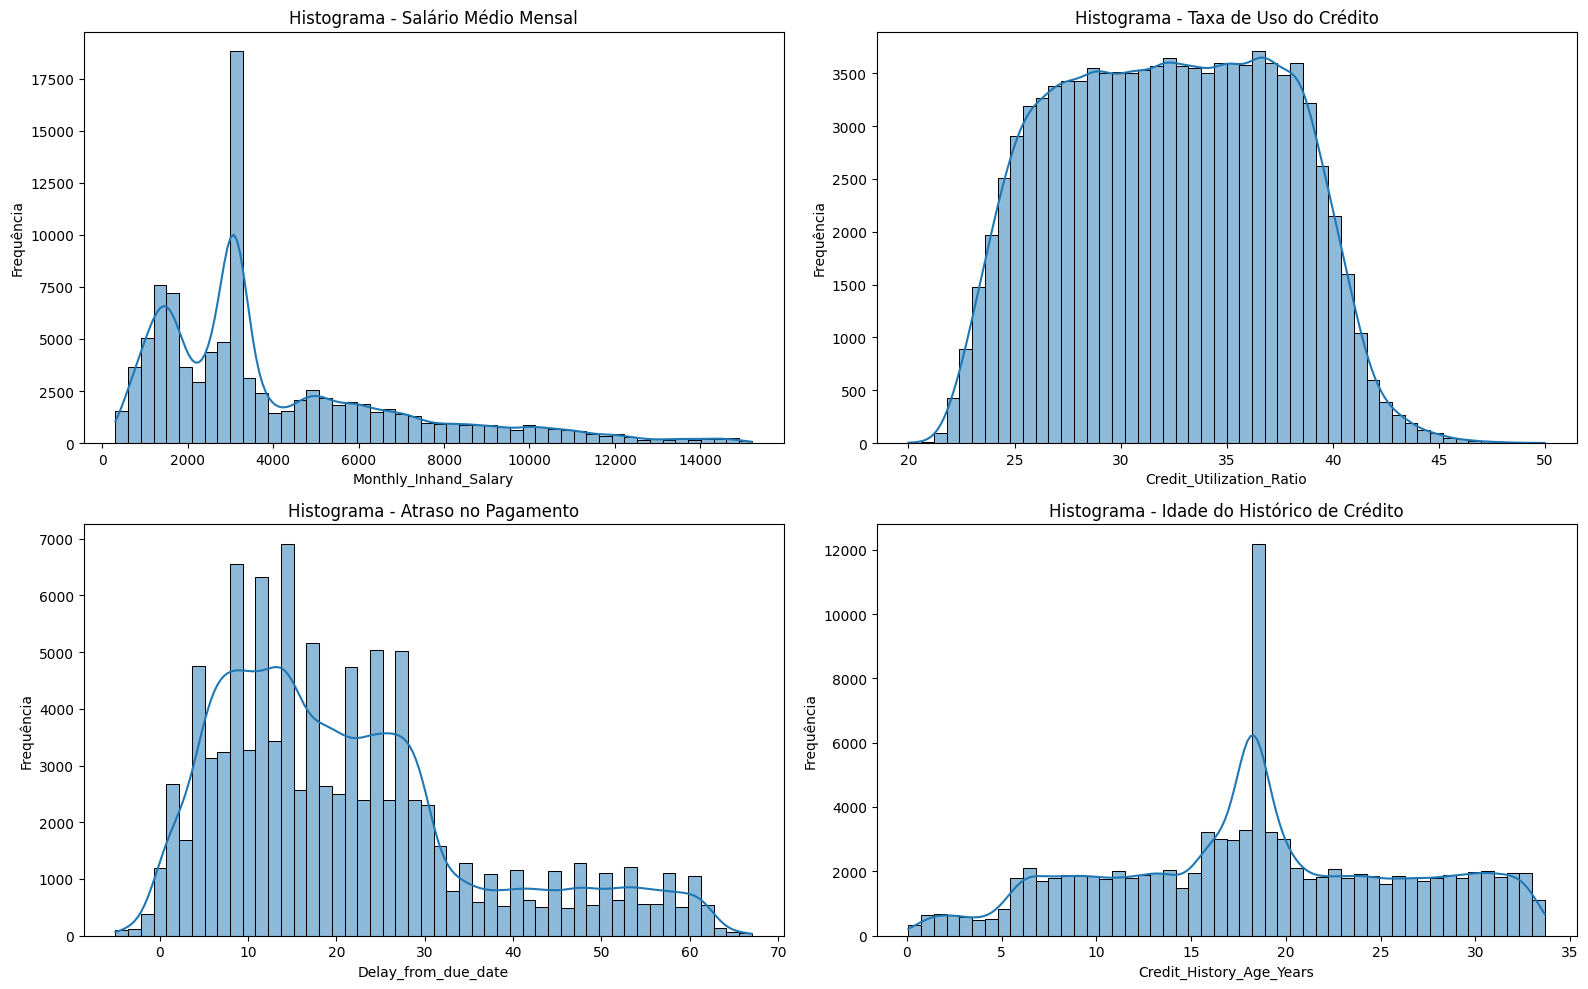

In [50]:
plt.figure(figsize=(16, 10))

# Monthly_Inhand_Salary
plt.subplot(2, 2, 1)
sns.histplot(
    data=df_treino,
    x='Monthly_Inhand_Salary',
    kde=True,
    bins=50
)
plt.title('Histograma - Salário Médio Mensal')
plt.ylabel('Frequência')

# Credit_Utilization_Ratio
plt.subplot(2, 2, 2)
sns.histplot(
    data=df_treino,
    x='Credit_Utilization_Ratio',
    kde=True,
    bins=50
)
plt.title('Histograma - Taxa de Uso do Crédito')
plt.ylabel('Frequência')

# Delay_from_due_date
plt.subplot(2, 2, 3)
sns.histplot(
    data=df_treino,
    x='Delay_from_due_date',
    kde=True,
    bins=50
)
plt.title('Histograma - Atraso no Pagamento')
plt.ylabel('Frequência')

# Credit_History_Age
plt.subplot(2, 2, 4)
sns.histplot(
    data=df_treino,
    x='Credit_History_Age_Years',
    kde=True,
    bins=50
)
plt.title('Histograma - Idade do Histórico de Crédito')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

#### Salário Mensal e Credit Score

Podemos ver que há uma relação entre o salário mensal e o credit score. Os créditos com score mais altos possuem range de salário maior, de até 8.000.

<Axes: xlabel='Credit_Score', ylabel='Monthly_Inhand_Salary'>

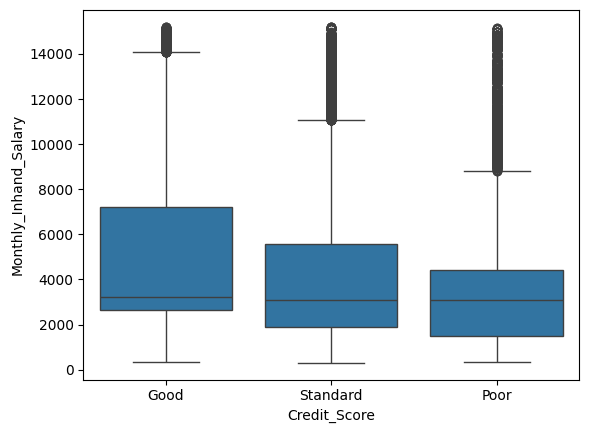

In [51]:
sns.boxplot(data=df_treino, x='Credit_Score', y='Monthly_Inhand_Salary')

### Fidelidade de Crédito e Credit Score

Vemos que há uma relação entre a fidelidade de crédito e o credit score. Os clientes com score mais altos possuem fidelidade de crédito mais alta, de até 300 meses (aproximadamente 25 a 30 anos)

<Axes: xlabel='Credit_Score', ylabel='Credit_History_Age_Years'>

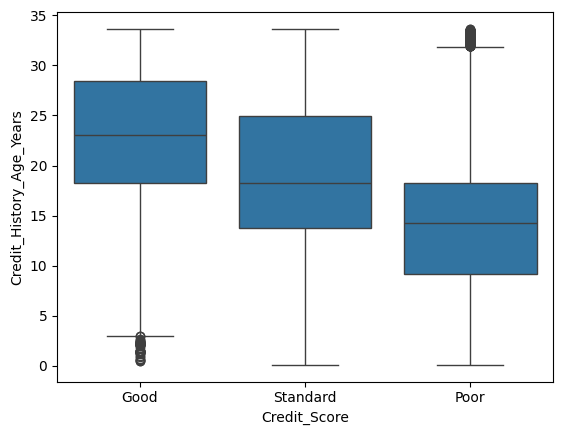

In [52]:
sns.boxplot(data=df_treino, x='Credit_Score', y='Credit_History_Age_Years')

### Dívidas Pendentes e Credit Score

Correlação clássica: quem tem mais dívidas possui um score baixo, bem como dias de atraso maiores causam um score baixo.

<Axes: xlabel='Credit_Score', ylabel='Outstanding_Debt'>

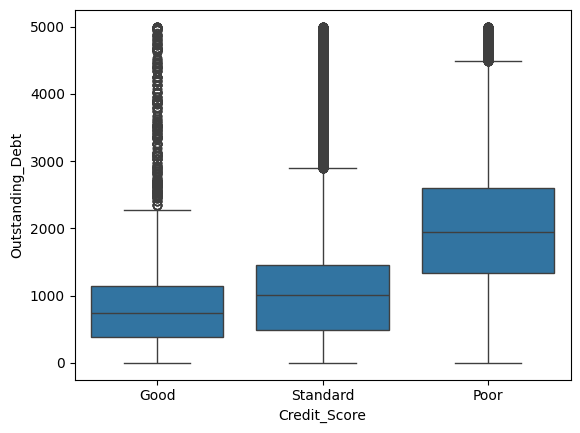

In [53]:
sns.boxplot(data=df_treino, x='Credit_Score', y='Outstanding_Debt')

<Axes: xlabel='Credit_Score', ylabel='Delay_from_due_date'>

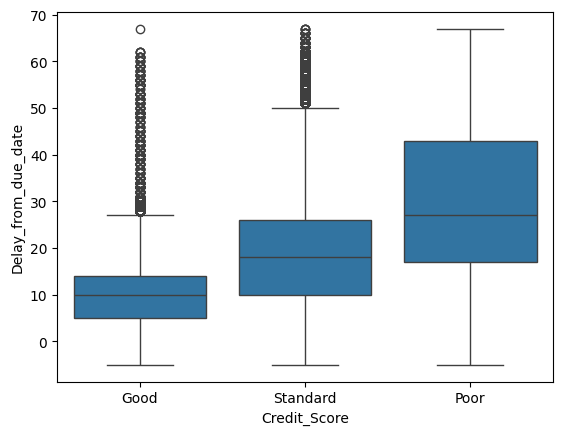

In [54]:
sns.boxplot(data=df_treino, x='Credit_Score', y='Delay_from_due_date')

### Matriz de Correlação - Variáveis Numéricas

A matriz de correlação é uma ferramenta de análise exploratória utilizada para medir a intensidade e a direção da relação linear entre variáveis numéricas. Ela é representada por uma tabela em que cada célula contém um coeficiente de correlação entre duas variáveis, normalmente o coeficiente de Pearson, cujo valor varia de -1 a 1.

A interpretação dos valores é a seguinte:

- +1: correlação positiva perfeita. Quando uma variável aumenta, a outra também aumenta na mesma proporção.
- 0: ausência de correlação linear. Não há relação linear entre as variáveis.
- -1: correlação negativa perfeita. Quando uma variável aumenta, a outra diminui na mesma proporção.

No estudo abaixo, a que mai chamou a atenção foi a relação entre Delay_from_Due_Date e Outstanding_Debt, mostrando que quanto mais a pessoa demora para pagar o cartão de crédito, mais a dívida aumenta (por conta dos juros).

O contrário também é válido: Outstanding_Debt e Credit_Score_Age são variáveis opostas. Ou seja, quanto mais tempo a pessoa possui o cartão de crédito, menor é a dívida, demonstrando organização financeira e fidelidade aos prazos.

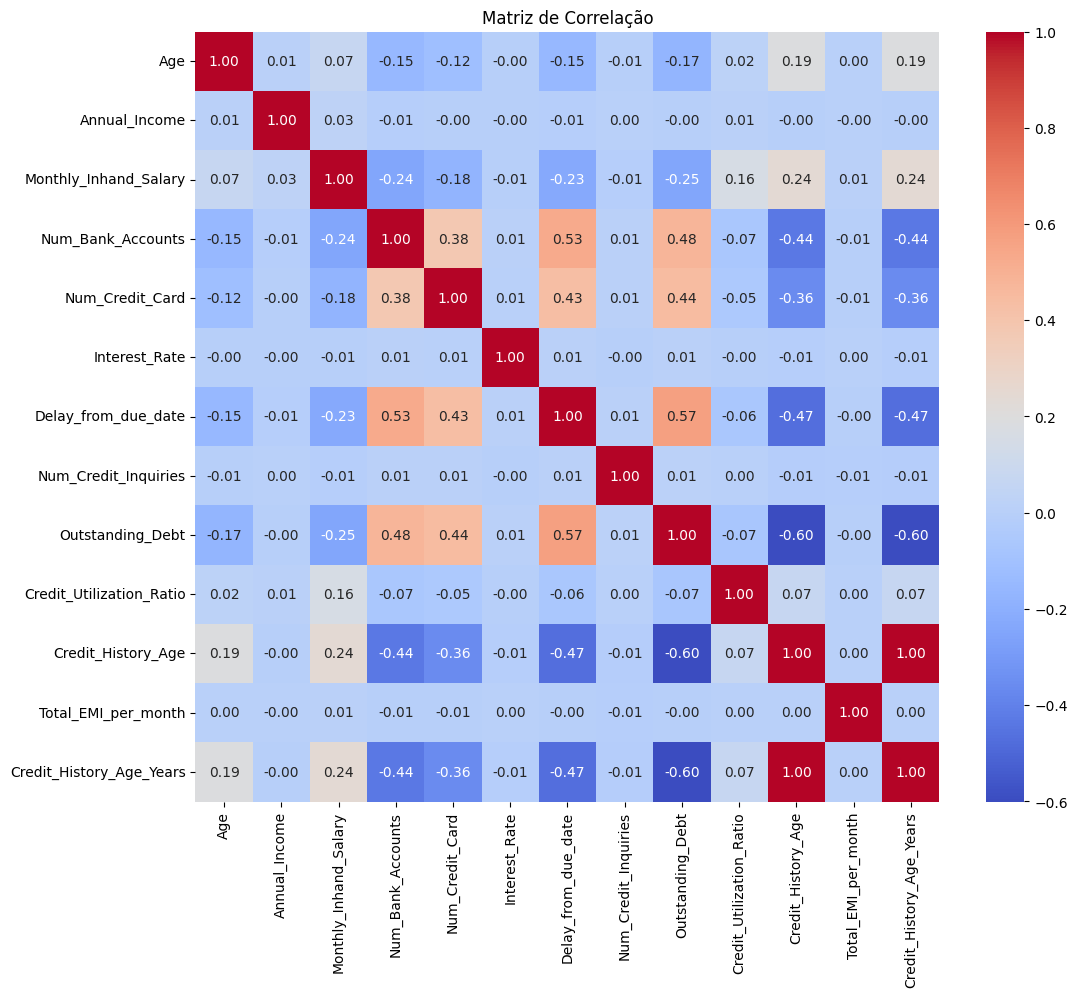

In [55]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df_treino.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de Correlação')
plt.show()

### Matriz de Correlação - Variáveis Categóricas (Ocupação e Credit Score)

Essa matriz nos revela um fato curioso: as ocupações que mais possuem pessoas com um bom credit score são engenheiro, jornalista, gerente de mídias e músico. Talvez possamos descobrir uma causalidade para esse fato mais adiante, mas no geral, a distribuição de credit score por ocupação é bastante homogênea, não revelando algo significativo. 

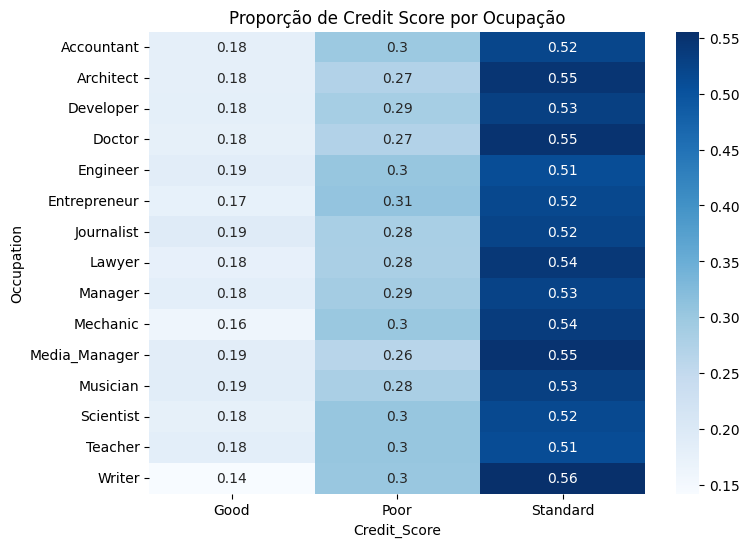

In [56]:
tabela = pd.crosstab(
    df_treino['Occupation'],
    df_treino['Credit_Score'],
    normalize='index'
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    tabela,
    annot=True,
    cmap='Blues'
)
plt.title('Proporção de Credit Score por Ocupação')
plt.show()

-----

# 4. Modelagem Preditiva

Os dois modelos escolhidos foram LightGBM e Regressão Logística, explicados mais à frente.

Como meu objetivo é comparar os modelos para uma base de Score de Crédito, a escolha das métricas certas é extremamente importante. No contexto financeiro, uma previsão errada de um cliente inadimplente (Falso Negativo) custa muito mais caro do que recusar um bom cliente (Falso Positivo), pois perder dinheiro é pior do que deixar de lucrar.

Dito isso, para este cenário, nunca posso usar a Acurácia isolada, pois se 95% da base for de bons pagadores, um modelo burro que aprova todo mundo terá 95% de acurácia (possível overfitting), mas quebrará a empresa. 

Focarei em:

- AUC-ROC (Área sob a Curva ROC): capacidade do modelo de separar os bons dos maus pagadores. Varia de 0.5 (aleatório) a 1.0 (perfeito). Um bom modelo de crédito passa de 0.75.

- Coeficiente Gini: métrica padrão dos bancos. Calculada como Gini = (2 × AUC) - 1. Valores acima de 0.50 indicam um modelo forte. É apenas uma forma visualmente mais agressiva do AUC-ROC para a tomada de decisão.
  
- Recall (Sensibilidade): dos clientes que realmente eram maus pagadores (poor score), quantos o modelo conseguiu detectar? É importante para reduzir o prejuízo financeiro. Quando o modelo diz que alguém tem poor score, qual a chance de ele estar certo? Evita que recuse bons clientes injustamente.


#### KPIs do Projeto

O Data Girls Finance tem como meta o monitoramento de KPIs técnicos.

**KPIs técnicos**
- Coeficiente Gini (Meta: > 0.45): resume a capacidade do modelo de garantir que clientes com scores menores realmente fiquem mais inadimplentes que clientes com scores maiores.
- AUC-ROC (Meta: > 0.75): avalia a separabilidade global entre score bom e ruim.
- Taxa de Falsos Negativos - FNR (Meta: A menor possível): vai ditar o tamanho do prejuízo financeiro (pessoas inadimplentes que foram classificadas como good score).
- Estabilidade do Modelo (PSI - Population Stability Index): Mede o quanto a base de clientes atual mudou em relação à base de 100 mil linhas usada no treino. Um PSI > 0.25 indica que o perfil do público mudou e o modelo precisa ser readequado.

--------

## Feature Engineering

Para ficar em conformidade com a LGPD, vamos remover as colunas de ID, Customer_ID, Name e SSN. São identificadores e não agregam ao nosso modelo.

In [57]:
colunas_remover = ['ID', 'Customer_ID', 'Name', 'SSN']

df_treino = df_treino.drop(columns=colunas_remover)
df_teste = df_teste.drop(columns=colunas_remover)

**Criando novas variáveis**

Durante a feature engineering, podemos criar novas variáveis que façam sentido juntando as que já existem, por exemplo:

Debt_to_Income: Essa variável mede a proporção da dívida total em relação à renda anual do cliente. Ela indica o quanto da renda está comprometida com dívidas, sendo um dos indicadores mais importantes de risco financeiro. Por exemplo, um Debt_to_Income de 2.8 signfica que a dívida da pessoa é quase 3 vezes maior que o salário dela (280%).

Investment_Ratio: Representa a fração da renda mensal que o cliente investe. Ela é calculada a partir do valor investido mensalmente dividido pelo salário mensal. Essa variável ajuda a identificar hábitos financeiros mais saudáveis.

In [58]:
def criar_features_basicas(df):
    df = df.copy()

    # Garantir que são numéricas (evita erro str / float)
    df['Annual_Income'] = pd.to_numeric(df['Annual_Income'], errors='coerce')
    df['Monthly_Inhand_Salary'] = pd.to_numeric(df['Monthly_Inhand_Salary'], errors='coerce')
    df['Outstanding_Debt'] = pd.to_numeric(df['Outstanding_Debt'], errors='coerce')
    df['Amount_invested_monthly'] = pd.to_numeric(df['Amount_invested_monthly'], errors='coerce')

    # Evitar divisão por zero
    income_safe = df['Annual_Income'].replace(0, np.nan)
    salary_safe = df['Monthly_Inhand_Salary'].replace(0, np.nan)

    # 1. Debt to Income
    # Mede comprometimento da renda
    df['Debt_to_Income'] = df['Outstanding_Debt'] / income_safe

    # 2. Investment Ratio
    # Indica hábito de investimento
    df['Investment_Ratio'] = df['Amount_invested_monthly'] / salary_safe

    # Limpar infinitos
    df = df.replace([np.inf, -np.inf], np.nan)

    return df

In [59]:
df_treino = criar_features_basicas(df_treino)
df_teste = criar_features_basicas(df_teste)

In [60]:
df_treino

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Credit_History_Age_Years,Debt_to_Income,Investment_Ratio
0,January,23,Scientist,19114.12,1824.843333,3,4.0,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,265.0,No,49.574949,80.415295,High_spent_Small_value_payments,312.49408867943663,Good,22.083333,0.042376,0.044067
1,February,23,Scientist,19114.12,3093.745000,3,4.0,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,219.0,No,49.574949,118.280222,Low_spent_Large_value_payments,284.62916249607184,Good,18.250000,0.042376,0.038232
2,March,-3,Scientist,19114.12,3093.745000,3,4.0,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,267.0,No,49.574949,81.699521,Low_spent_Medium_value_payments,331.2098628537912,Good,22.250000,0.042376,0.026408
3,April,23,Scientist,19114.12,3093.745000,3,4.0,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,268.0,No,49.574949,199.458074,Low_spent_Small_value_payments,223.45130972736786,Good,22.333333,0.042376,0.064471
4,May,23,Scientist,19114.12,1824.843333,3,4.0,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,269.0,No,49.574949,41.420153,High_spent_Medium_value_payments,341.48923103222177,Good,22.416667,0.042376,0.022698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,April,25,Mechanic,39628.99,3359.415833,4,6.0,7,2,"Auto Loan, and Student Loan",...,378.0,No,35.104023,60.971333,High_spent_Large_value_payments,479.866228,Poor,31.500000,0.012677,0.018149
99996,May,25,Mechanic,39628.99,3359.415833,4,6.0,7,2,"Auto Loan, and Student Loan",...,379.0,No,35.104023,54.185950,High_spent_Medium_value_payments,496.65161,Poor,31.583333,0.012677,0.016130
99997,June,25,Mechanic,39628.99,3359.415833,4,6.0,5729,2,"Auto Loan, and Student Loan",...,380.0,No,35.104023,24.028477,High_spent_Large_value_payments,516.809083,Poor,31.666667,0.012677,0.007153
99998,July,25,Mechanic,39628.99,3359.415833,4,6.0,7,2,"Auto Loan, and Student Loan",...,381.0,No,35.104023,251.672582,Low_spent_Large_value_payments,319.164979,Standard,31.750000,0.012677,0.074916


----------

## Modelo 1 - LightGBM

O LightGBM é uma biblioteca da Microsoft baseada em árvore de decisão. É um dos campeões em dados tabulares, além de ser extremamente rápido para 100 mil linhas. Uma das vantagens para o nosso cenário é o fato de lidar bem com dados ausentes e corrigir o desbalanceamento de classes (good vs poor score).

In [61]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, f1_score # <-- F1_SCORE ADICIONADO

# ============================================================
# PASSO 1: LIMPEZA E TRATAMENTO FINAL DOS DADOS
# Foi necessária uma limpeza específica para o LightGBM, pois a limpeza anterior não foi suficiente.
# ============================================================

colunas_numericas_sujas = [
    'Num_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 
    'Monthly_Balance', 'Age', 'Credit_History_Age'    
]

for df in [df_treino, df_teste]:
    for col in colunas_numericas_sujas:
        if col in df.columns:
            if col == 'Credit_History_Age':
                df[col] = df[col].astype(str).str.extract(r'(\d+)')
            df[col] = df[col].astype(str).str.strip()
            df[col] = pd.to_numeric(df[col], errors='coerce')

df_treino = df_treino.dropna(subset=['Credit_Score']).copy()
df_treino['Credit_Score'] = df_treino['Credit_Score'].astype(str).str.strip()

le = LabelEncoder()
df_treino['Credit_Score'] = le.fit_transform(df_treino['Credit_Score'])
num_classes = len(le.classes_)

colunas_cat = [
    'Month', 'Type_of_Loan', 'Payment_of_Min_Amount',
    'Occupation', 'Credit_Mix', 'Payment_Behaviour'    
]

for col in colunas_cat:
    if col in df_treino.columns:
        df_treino[col] = df_treino[col].astype('category')
    if col in df_teste.columns:
        df_teste[col] = df_teste[col].astype('category')

# ============================================================
# PASSO 2: SEPARAÇÃO E ALINHAMENTO DE FEATURES (X) E TARGET (y)
# ============================================================
X = df_treino.drop(columns=['Credit_Score'])  
y = df_treino['Credit_Score'].reset_index(drop=True)

X_test = df_teste.copy()
if 'Credit_Score' in X_test.columns:
    X_test = X_test.drop(columns=['Credit_Score'])

X_test = X_test.reindex(columns=X.columns)

# ============================================================
# PASSO 3: CONFIGURAÇÃO DO CROSS-VALIDATION
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

aucs = []
ginis = []
fnrs = []
acuracias = [] 
f1_scores = []
test_preds_proba = np.zeros((len(X_test), num_classes)) 

# Configurando hiperparâmetros
params = {
    'objective': 'multiclass',        
    'num_class': num_classes,                   
    'n_estimators': 500,              
    'learning_rate': 0.05,           
    'max_depth': -1,                 
    'num_leaves': 100,                
    'min_child_samples': 20,         
    'subsample': 0.8,                
    'colsample_bytree': 0.8,         
    'random_state': 42,
    'verbose': -1  
}

print("--- INICIANDO VALIDAÇÃO CRUZADA (LightGBM) ---")

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
    X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
    X_val_fold, y_val_fold = X.iloc[val_idx], y.iloc[val_idx]
    
    modelo_lgb = lgb.LGBMClassifier(**params)
    modelo_lgb.fit(X_train_fold, y_train_fold, categorical_feature=colunas_cat)
    
    val_proba = modelo_lgb.predict_proba(X_val_fold)
    val_pred = np.argmax(val_proba, axis=1)
    
    # Calcular métricas locais
    fold_auc = roc_auc_score(y_val_fold, val_proba, multi_class='ovr')
    fold_gini = 2 * fold_auc - 1
    fold_acc = accuracy_score(y_val_fold, val_pred)
    fold_f1 = f1_score(y_val_fold, val_pred, average='macro')
    
    cm = confusion_matrix(y_val_fold, val_pred)
    fold_fnr = (cm.sum(axis=1) - np.diag(cm)) / cm.sum(axis=1)
    
    # Salvar nas listas
    aucs.append(fold_auc)
    ginis.append(fold_gini)
    fnrs.append(fold_fnr)
    acuracias.append(fold_acc)
    f1_scores.append(fold_f1)
    
    print(f"Fold {fold} | AUC: {fold_auc:.4f} | Gini: {fold_gini:.4f} | ACC: {fold_acc:.4f} | F1-Macro: {fold_f1:.4f}")
    
    test_preds_proba += modelo_lgb.predict_proba(X_test) / cv.n_splits

print("-" * 65)

# ============================================================
# PASSO 4: EXIBIÇÃO DOS RESULTADOS CONSOLIDADOS
# ============================================================
print("\n--- PERFORMANCE MÉDIA (CV) ---")
print(f"Acurácia Média: {np.mean(acuracias):.4f}")
print(f"F1-Score Médio: {np.mean(f1_scores):.4f}")
print(f"AUC-ROC Médio:  {np.mean(aucs):.4f}")
print(f"Gini Médio:     {np.mean(ginis):.4f}")

fnr_medio = np.mean(np.array(fnrs), axis=0)
for idx, classe in enumerate(le.classes_):
    print(f"FNR Médio - {classe} ({idx}): {fnr_medio[idx]:.4f}")
print("-" * 30)

# ============================================================
# PASSO 5: PREVISÃO FINAL 
# ============================================================
y_test_pred_final = np.argmax(test_preds_proba, axis=1)
df_resultados_teste = df_teste.copy()
df_resultados_teste['Credit_Score_Predicted'] = le.inverse_transform(y_test_pred_final)

print("\n[Sucesso] LightGBM concluído!")


--- INICIANDO VALIDAÇÃO CRUZADA (LightGBM) ---
Fold 1 | AUC: 0.9311 | Gini: 0.8622 | ACC: 0.8129 | F1-Macro: 0.8034
Fold 2 | AUC: 0.9285 | Gini: 0.8570 | ACC: 0.8107 | F1-Macro: 0.8007
Fold 3 | AUC: 0.9311 | Gini: 0.8623 | ACC: 0.8154 | F1-Macro: 0.8063
Fold 4 | AUC: 0.9290 | Gini: 0.8580 | ACC: 0.8116 | F1-Macro: 0.8032
Fold 5 | AUC: 0.9278 | Gini: 0.8555 | ACC: 0.8060 | F1-Macro: 0.7965
-----------------------------------------------------------------

--- PERFORMANCE MÉDIA (CV) ---
Acurácia Média: 0.8113
F1-Score Médio: 0.8020
AUC-ROC Médio:  0.9295
Gini Médio:     0.8590
FNR Médio - Good (0): 0.2409
FNR Médio - Poor (1): 0.1876
FNR Médio - Standard (2): 0.1718
------------------------------

[Sucesso] LightGBM concluído!


----

### Comparação entre datasets de treino e teste no LightGBM

Agora, faremos a comparação entre o dataset de treino e o dataset de teste após a aplicação do modelo. 

Ao analisar o gráfico, podemos concluir que os clientes com score "Standard" (ou seja, padrão) tendem a diminuir 3 pontos percentuais. Ao balancear as classes, os clientes com score bom e ruim aumentaram apenas 2 pontos, aproximadamente.

Não é um bom cenário, visto que a Data Girls Finance é uma fintech que incentiva o bom uso de crédito e uma relação saudável com as finanças. Podemos pensar em estratégias para reter clientes no cenário de crédito de uma forma positiva, já que não obtivemos grandes aumentos na classe Good.

Por exemplo, a variável de Credit_History_Age_Years (há quanto tempo o cliente utiliza o crédito) e a variável de Outstanding_Debt (valor da dívida pendente) são diretamente relacionadas em direção oposta: quanto mais a fidelidade do cliente, menor é o valor da dívida pendente. Como poderíamos diminuir a inadimplência, incentivando aumentar a fidelidade dos clientes?

--- ANÁLISE COMPARATIVA DE DISTRIBUIÇÃO ---
          Treino (Histórico %)  Teste (Previsto %)  Diferença (p.p.)
Standard                 53.17               50.49             -2.69
Poor                     29.00               30.27              1.27
Good                     17.83               19.24              1.41
-------------------------------------------

--- CONCLUSÃO GERAL ---
Houve uma mudança significativa do score Standard. A coluna 'Diferença (p.p.)' possui mais detalhes sobre a variância entre datasets.


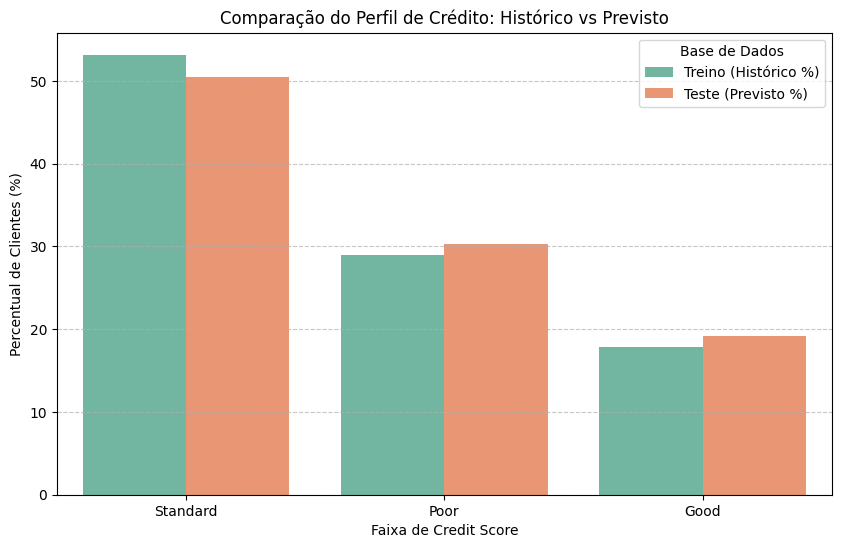

In [62]:
# ============================================================
# 1. RECUPERAR TEXTOS ORIGINAIS DO TREINO (Para comparação justa)
# ============================================================
df_treino_analise = df_treino.copy()
df_treino_analise['Credit_Score_Original'] = le.inverse_transform(df_treino_analise['Credit_Score'])

# ============================================================
# 2. CALCULAR DISTRIBUIÇÃO PERCENTUAL
# ============================================================
dist_treino = df_treino_analise['Credit_Score_Original'].value_counts(normalize=True) * 100
dist_teste = df_resultados_teste['Credit_Score_Predicted'].value_counts(normalize=True) * 100

# Criar um DataFrame comparativo
df_comparativo = pd.DataFrame({
    'Treino (Histórico %)': dist_treino,
    'Teste (Previsto %)': dist_teste
}).fillna(0)

# Calcular a diferença (Teste - Treino)
df_comparativo['Diferença (p.p.)'] = df_comparativo['Teste (Previsto %)'] - df_comparativo['Treino (Histórico %)']

print("--- ANÁLISE COMPARATIVA DE DISTRIBUIÇÃO ---")
print(df_comparativo.round(2))
print("-" * 43)

# ============================================================
# 3. DIAGNÓSTICO AUTOMÁTICO DO SCORE GERAL
# ============================================================
# Pegamos a diferença da categoria 'Good' (se houver) e 'Poor'
diff_good = df_comparativo.loc['Good', 'Diferença (p.p.)'] if 'Good' in df_comparativo.index else 0
diff_poor = df_comparativo.loc['Poor', 'Diferença (p.p.)'] if 'Poor' in df_comparativo.index else 0

print("\n--- CONCLUSÃO GERAL ---")
if diff_good > 0 and diff_poor <= 0:
    print(f"O score geral AUMENTOU. A proporção de clientes 'Good' subiu {diff_good:.2f} pontos percentuais.")
elif diff_poor > 0 and diff_good <= 0:
    print(f"O score geral DIMINUIU. A proporção de clientes 'Poor' aumentou {diff_poor:.2f} pontos percentuais.")
else:
    print(f"Houve uma mudança significativa do score Standard. A coluna 'Diferença (p.p.)' possui mais detalhes sobre a variância entre datasets.")

# ============================================================
# 4. VISUALIZAÇÃO GRÁFICA (Gráfico de Barras Lado a Lado)
# ============================================================
# Prepara os dados para o formato do Seaborn
df_plot = df_comparativo.reset_index().melt(id_vars='index', value_vars=['Treino (Histórico %)', 'Teste (Previsto %)'])
df_plot.columns = ['Categoria', 'Base de Dados', 'Percentual']

plt.figure(figsize=(10, 6))
sns.barplot(x='Categoria', y='Percentual', hue='Base de Dados', data=df_plot, palette='Set2')
plt.title('Comparação do Perfil de Crédito: Histórico vs Previsto')
plt.ylabel('Percentual de Clientes (%)')
plt.xlabel('Faixa de Credit Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


----------

## Modelo 2 - Regressão Logística

A Regressão Logística é um modelo linear clássico, amplamente utilizado em scorecard de crédito pela sua interpretabilidade. Diferente do LightGBM, ela não lida nativamente com variáveis categóricas nem com dados ausentes, portanto é necessário um pipeline de pré-processamento:

- **OrdinalEncoder** para as variáveis categóricas (encoding ordinal simples é suficiente aqui pois não há relação de ordem explorada diretamente, o modelo aprende os pesos lineares de cada categoria).
- **StandardScaler** para normalizar as variáveis numéricas (a RL é sensível à escala).
- **LogisticRegression** com `solver='saga'` para o problema de 3 classes (Good / Poor / Standard).

Usaremos o mesmo `StratifiedKFold` (5 folds, `random_state=42`) definido no Modelo 1 para garantir comparação justa.

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, f1_score
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# ============================================================
# PASSO 1: PREPARAR AS FEATURES PARA A REGRESSÃO LOGÍSTICA
# Mesmo caso do LightGBM, tivemos que fazer uma limpeza extra.
# ============================================================
colunas_cat_lr = [
    'Month', 'Type_of_Loan', 'Payment_of_Min_Amount',
    'Occupation', 'Credit_Mix', 'Payment_Behaviour'
]
colunas_num_lr = [c for c in X.columns if c not in colunas_cat_lr]

X_lr = X.copy()
for col in colunas_cat_lr:
    if col in X_lr.columns:
        X_lr[col] = X_lr[col].astype(str)

X_test_lr = X_test.copy()
for col in colunas_cat_lr:
    if col in X_test_lr.columns:
        X_test_lr[col] = X_test_lr[col].astype(str)

# ============================================================
# PASSO 2: PIPELINE (Imputer → Scaler/Encoder → LogReg)
# ============================================================
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', make_pipeline(
            SimpleImputer(strategy='median'),
            StandardScaler()
        ), colunas_num_lr),
        ('cat', make_pipeline(
            SimpleImputer(strategy='most_frequent'),
            OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        ), colunas_cat_lr)
    ],
    remainder='drop'
)

# Configurando hiperparâmetros

pipeline_lr = Pipeline([
    ('pre', preprocessor_lr),
    ('clf', LogisticRegression(
        solver='saga',
        max_iter=700,
        C=0.1,
        random_state=42
    ))
])

# ============================================================
# PASSO 3: VALIDAÇÃO CRUZADA (mesmo cv do LightGBM)
# ============================================================
aucs_lr      = []
ginis_lr     = []
fnrs_lr      = []
acuracias_lr = []
f1_scores_lr = []
test_preds_proba_lr = np.zeros((len(X_test_lr), num_classes))

print("--- INICIANDO VALIDAÇÃO CRUZADA (Regressão Logística) ---")

for fold, (train_idx, val_idx) in enumerate(cv.split(X_lr, y), 1):
    X_train_fold = X_lr.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_val_fold   = X_lr.iloc[val_idx]
    y_val_fold   = y.iloc[val_idx]

    pipeline_lr.fit(X_train_fold, y_train_fold)

    val_proba = pipeline_lr.predict_proba(X_val_fold)
    val_pred  = np.argmax(val_proba, axis=1)

    fold_auc  = roc_auc_score(y_val_fold, val_proba, multi_class='ovr')
    fold_gini = 2 * fold_auc - 1
    fold_acc  = accuracy_score(y_val_fold, val_pred)
    fold_f1   = f1_score(y_val_fold, val_pred, average='macro')

    cm_lr       = confusion_matrix(y_val_fold, val_pred)
    fold_fnr_lr = (cm_lr.sum(axis=1) - np.diag(cm_lr)) / cm_lr.sum(axis=1)

    aucs_lr.append(fold_auc)
    ginis_lr.append(fold_gini)
    fnrs_lr.append(fold_fnr_lr)
    acuracias_lr.append(fold_acc)
    f1_scores_lr.append(fold_f1)

    test_preds_proba_lr += pipeline_lr.predict_proba(X_test_lr) / cv.n_splits

    print(f"Fold {fold} | AUC: {fold_auc:.4f} | Gini: {fold_gini:.4f} | ACC: {fold_acc:.4f} | F1-Macro: {fold_f1:.4f}")

print("-" * 65)

# ============================================================
# PASSO 4: RESULTADOS CONSOLIDADOS
# ============================================================
print("\n--- PERFORMANCE MÉDIA (CV) - Regressão Logística ---")
print(f"Acurácia Média: {np.mean(acuracias_lr):.4f}")
print(f"F1-Score Médio: {np.mean(f1_scores_lr):.4f}")
print(f"AUC-ROC Médio:  {np.mean(aucs_lr):.4f}")
print(f"Gini Médio:     {np.mean(ginis_lr):.4f}")

fnr_medio_lr = np.mean(np.array(fnrs_lr), axis=0)
for idx, classe in enumerate(le.classes_):
    print(f"FNR Médio - {classe} ({idx}): {fnr_medio_lr[idx]:.4f}")
print("-" * 30)

# ============================================================
# PASSO 5: PREVISÃO FINAL NO CONJUNTO DE TESTE
# ============================================================
y_test_pred_lr = np.argmax(test_preds_proba_lr, axis=1)
df_resultados_teste_lr = df_teste.copy()
df_resultados_teste_lr['Credit_Score_Predicted_LR'] = le.inverse_transform(y_test_pred_lr)

print("\n[Sucesso] Regressão Logística concluída!")

--- INICIANDO VALIDAÇÃO CRUZADA (Regressão Logística) ---
Fold 1 | AUC: 0.7667 | Gini: 0.5333 | ACC: 0.5934 | F1-Macro: 0.4908
Fold 2 | AUC: 0.7729 | Gini: 0.5458 | ACC: 0.5945 | F1-Macro: 0.4935
Fold 3 | AUC: 0.7683 | Gini: 0.5367 | ACC: 0.5957 | F1-Macro: 0.4924
Fold 4 | AUC: 0.7694 | Gini: 0.5387 | ACC: 0.5912 | F1-Macro: 0.4861
Fold 5 | AUC: 0.7658 | Gini: 0.5316 | ACC: 0.5897 | F1-Macro: 0.4851
-----------------------------------------------------------------

--- PERFORMANCE MÉDIA (CV) - Regressão Logística ---
Acurácia Média: 0.5929
F1-Score Médio: 0.4896
AUC-ROC Médio:  0.7686
Gini Médio:     0.5372
FNR Médio - Good (0): 0.8188
FNR Médio - Poor (1): 0.5618
FNR Médio - Standard (2): 0.1847
------------------------------

[Sucesso] Regressão Logística concluída!


----------

## 5. Avaliação dos Modelos 

Comparando as métricas médias de validação cruzada entre os dois modelos: LightGBM vs Regressão Logística.

### Principais insights

O LightGBM vence em todas as métricas, mas o ponto mais crítico é o FNR dos clientes "Poor":

- LightGBM: erra 19% dos inadimplentes → aceitável
- Regressão Logística: erra 56% dos inadimplentes → inviável para produção

Em crédito, cada falso negativo é dinheiro perdido. Um modelo que não identifica mais da metade dos maus pagadores quebra a operação.

O resultado da RL não é surpresa, o problema tem relações não-lineares entre as features (por exemplo, a combinação de dívida alta + histórico curto + atraso frequente) que uma fronteira linear simplesmente não consegue capturar. O LightGBM, baseado em árvores, identifica essas interações naturalmente.

Portanto, vamos seguir com os resultados do LightGBM para o time de negócios.

--- COMPARAÇÃO FINAL DOS MODELOS ---
                     AUC-ROC    Gini  Acurácia  F1-Macro  FNR (Poor)
Modelo                                                              
LightGBM              0.9295  0.8590    0.8113    0.8020      0.1876
Regressão Logística   0.7686  0.5372    0.5929    0.4896      0.5618



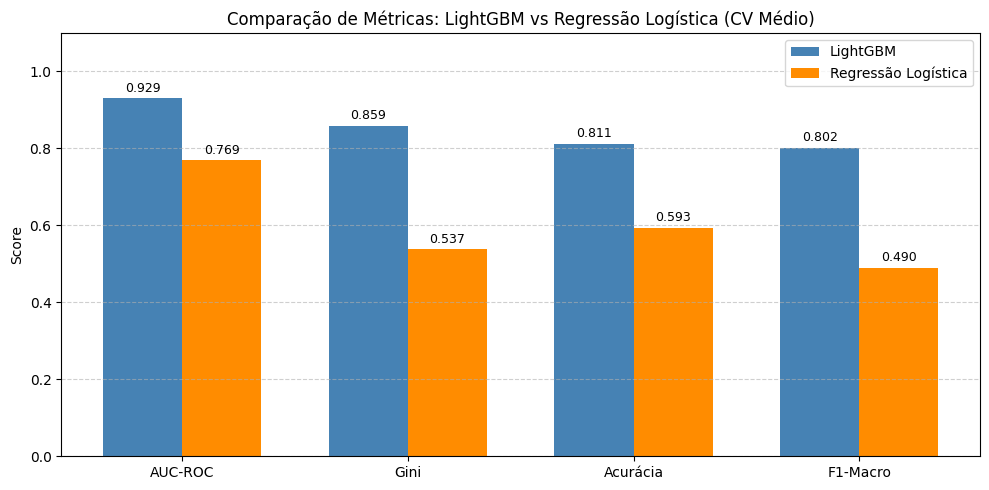

In [64]:
# ============================================================
# TABELA COMPARATIVA
# ============================================================
df_comparacao = pd.DataFrame({
    'Modelo':      ['LightGBM', 'Regressão Logística'],
    'AUC-ROC':     [np.mean(aucs),     np.mean(aucs_lr)],
    'Gini':        [np.mean(ginis),    np.mean(ginis_lr)],
    'Acurácia':    [np.mean(acuracias), np.mean(acuracias_lr)],
    'F1-Macro':    [np.mean(f1_scores), np.mean(f1_scores_lr)],
    'FNR (Poor)':  [np.mean(np.array(fnrs), axis=0)[1],
                    np.mean(np.array(fnrs_lr), axis=0)[1]]
}).set_index('Modelo').round(4)

print("--- COMPARAÇÃO FINAL DOS MODELOS ---")
print(df_comparacao.to_string())
print()

# ============================================================
# VISUALIZAÇÃO
# ============================================================
metricas = ['AUC-ROC', 'Gini', 'Acurácia', 'F1-Macro']
x = range(len(metricas))
largura = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar([i - largura/2 for i in x],
               df_comparacao.loc['LightGBM', metricas],
               largura, label='LightGBM', color='steelblue')
bars2 = ax.bar([i + largura/2 for i in x],
               df_comparacao.loc['Regressão Logística', metricas],
               largura, label='Regressão Logística', color='darkorange')

ax.set_xticks(list(x))
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Comparação de Métricas: LightGBM vs Regressão Logística (CV Médio)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


------
### Aplicando a ferramenta de interpretabilidade SHAP (explicabilidade local e global)

#### Explicabilidade global

Na etapa de explicabilidade global, utilizamos SHAP para entender o comportamento geral do modelo em uma amostra de 2000 observações.

Primeiro, calculamos os valores SHAP para todas as features e classes, obtendo a contribuição de cada variável nas predições do modelo. Em seguida, analisamos o impacto das features por classe, o que permitiu verificar como cada variável influencia diferentemente cada categoria do problema. 

Neste sentido, as variáveis mais relevantes para o modelo foram Type_of_Loan (tipo de empréstimo), Outstanding_Debt (dívida a pagar), e Interest_Rate (interesse em adquirir um cartão de crédito), pois apresentaram maior impacto médio absoluto nos valores SHAP ao longo da amostra analisada. Além disso, a análise por classe permitiu observar como a importância das features varia conforme a categoria prevista. Credit_Mix (variância de tipos de cartões de crédito), por exemplo, possui mais importância na classe Standard do que na classe Good.

Por fim, calculamos a média do valor absoluto dos SHAP values para obter a importância global das features, sintetizada em um gráfico de barras com o ranking das variáveis mais influentes.


#### Explicabilidade local

Na etapa de explicabilidade local, utilizamos SHAP para interpretar a previsão de um cliente específico do conjunto de teste. Ou seja, estamos respondendo à pergunta: por que o modelo classificou esse cliente nessa classe específica?

Primeiro, selecionamos uma observação individual e calculamos os valores SHAP, que representam a contribuição de cada variável na saída do modelo. Em seguida, identificamos a classe predita (neste caso, foi predita a classe Good [índice 0]). 

Utilizamos o gráfico waterfall para visualizar quais features aumentaram ou diminuíram a probabilidade dessa classe. Para entender melhor, vamos estudar o cenário de crédito em que estamos inseridos:

Vemos que a variável Type_of_Loan (tipo de empréstimo) possui alta influência na decisão. Existem os seguintes tipos de empréstimos possíveis neste dataset:

- Auto Loan: empréstimo destinado à compra ou financiamento de um veículo.
- Credit-Builder Loan: pequeno valor criado para ajudar o cliente a construir ou melhorar seu histórico de crédito.
- Debt Consolidation Loan: empréstimo utilizado para quitar várias dívidas existentes, reunindo-as em um único pagamento.
- Home Equity Loan: garantido pelo patrimônio (equidade) acumulado em um imóvel.
- Mortgage Loan: financiamento de longo prazo para aquisição de um imóvel, tendo o próprio imóvel como garantia.
- Payday Loan: empréstimo de curto prazo, geralmente com juros elevados, destinado a cobrir despesas até o próximo salário.
- Personal Loan: pessoal de uso livre, sem necessidade de informar uma finalidade específica.
- Student Loan: destinado ao financiamento de despesas educacionais, como mensalidades e custos acadêmicos.

Quando analisamos os tipos de empréstimos contratados pela classe predita, temos: Auto Loan, Credit Builder, Personal e Home Equity. Faz sentido que estejam em um credit score bom, pois são categorias consideradas melhores do que Mortgage e Payday, por exemplo. 

Por fim, também comparamos o mesmo cliente em todas as classes, permitindo entender não apenas por que a classe vencedora foi escolhida, mas também por que as demais classes tiveram menor evidência.


===== Impacto por feature para cada classe =====

=== Classe: Good ===


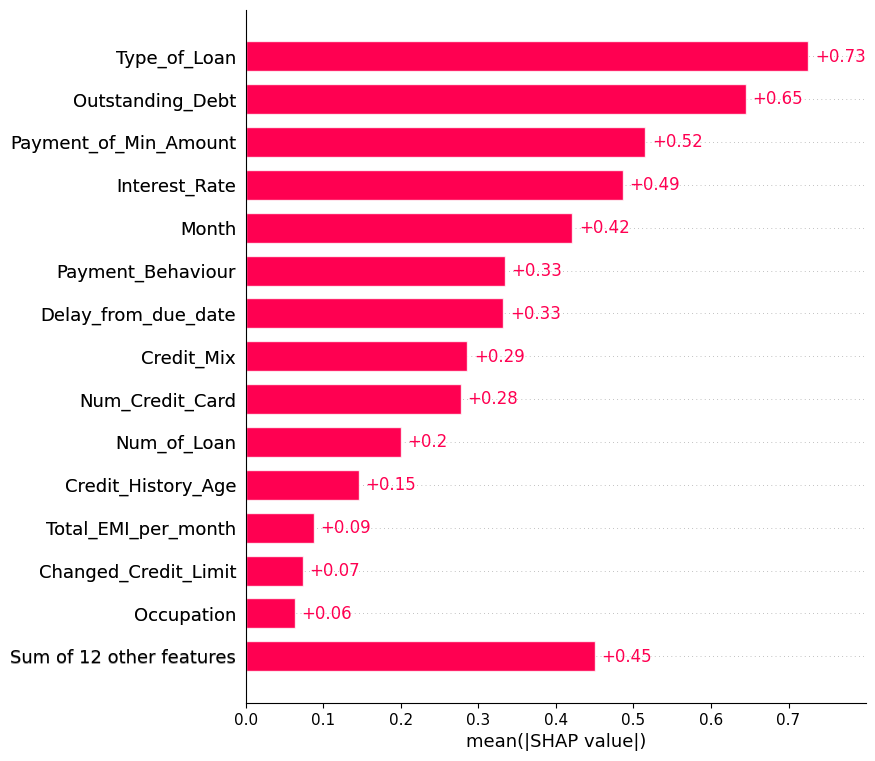


=== Classe: Poor ===


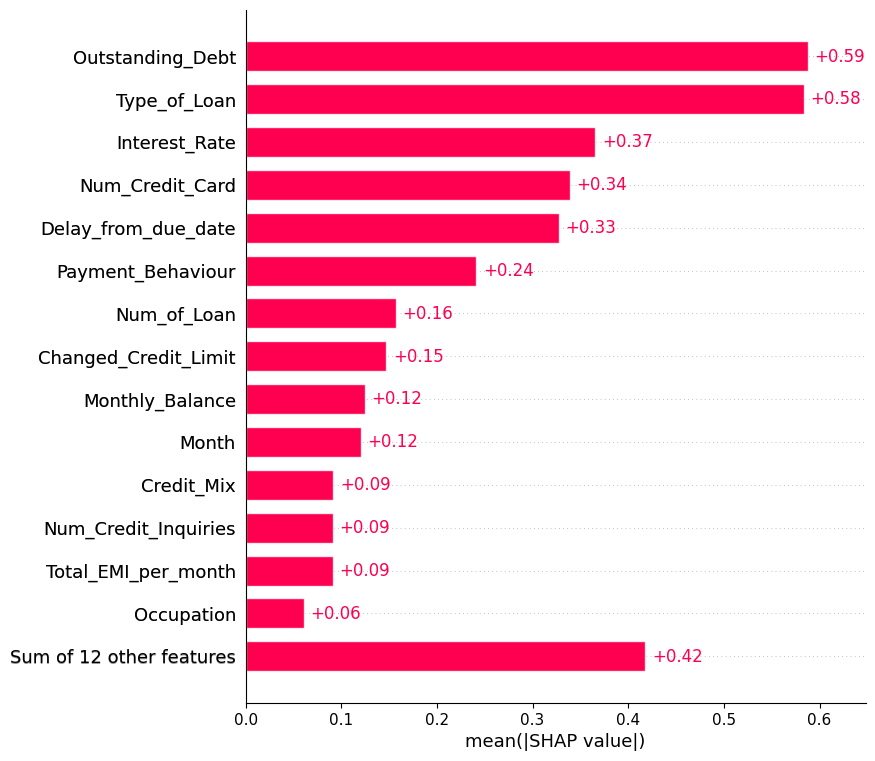


=== Classe: Standard ===


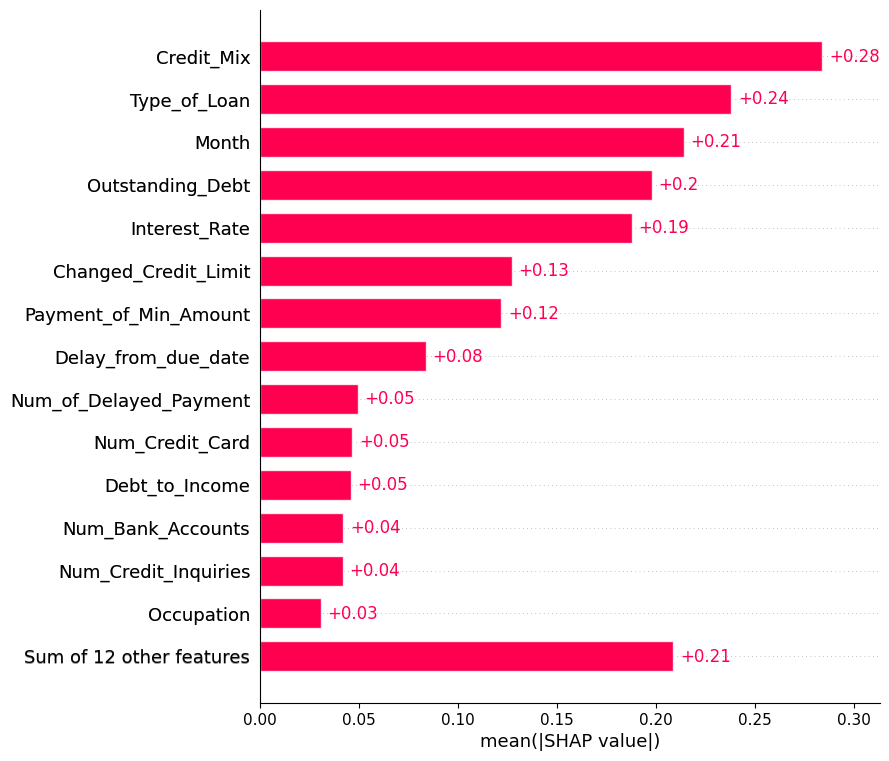


===== Importância média global (todas as classes) =====

=== Importância média por feature ===


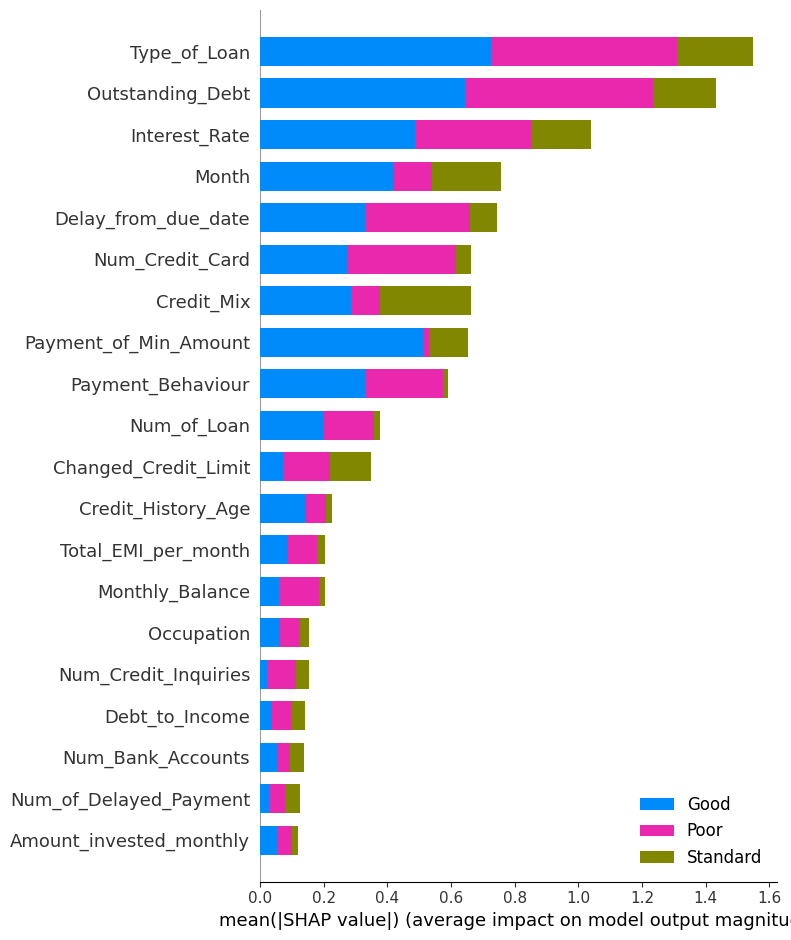


Classe predita: Good (índice 0)


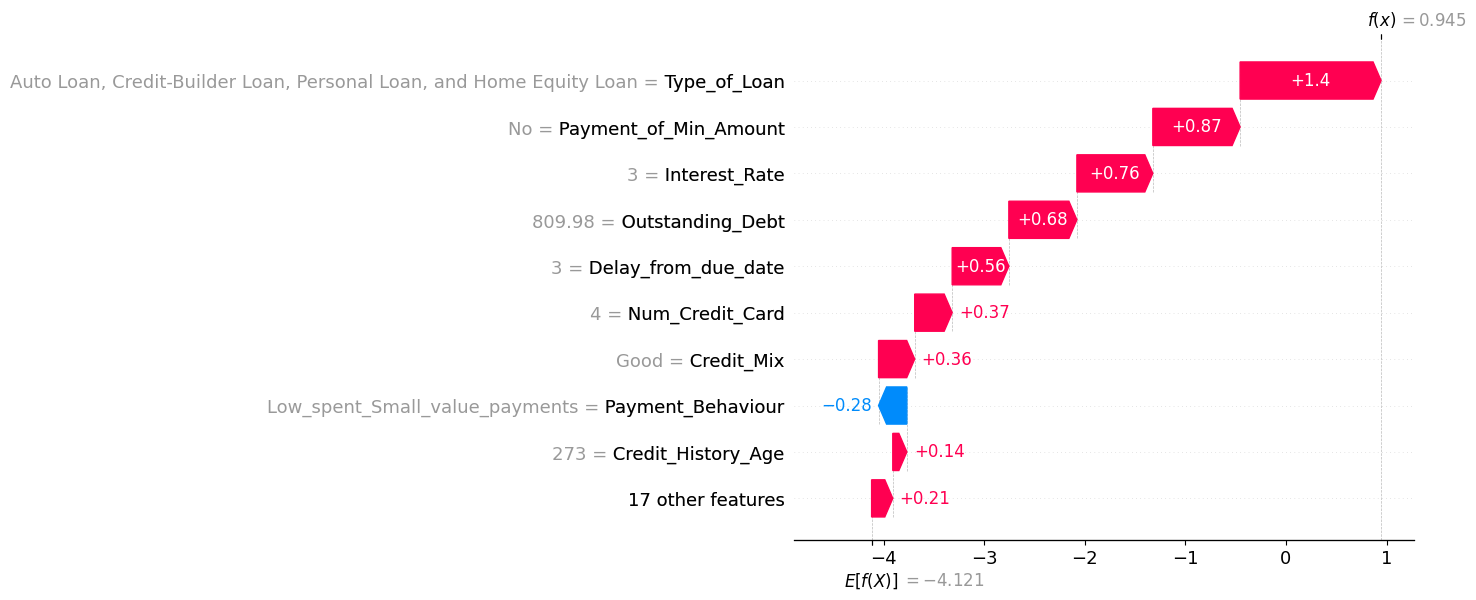


--- Explicação para classe: Good ---


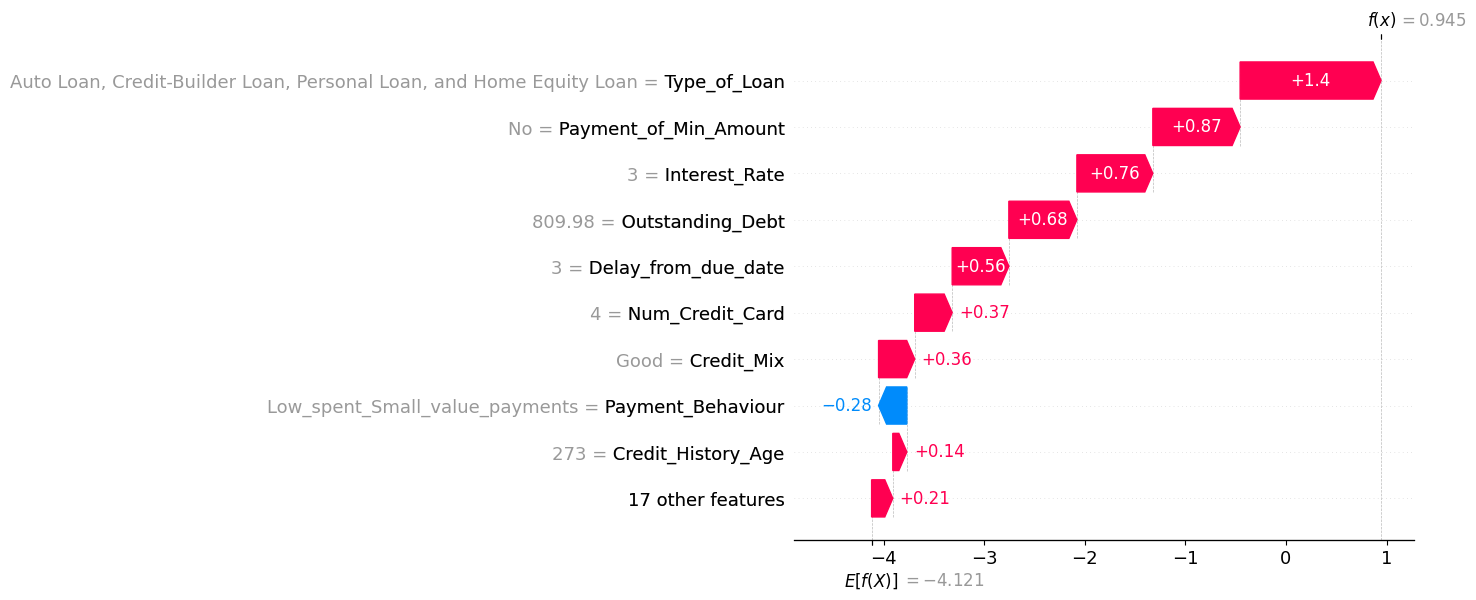


--- Explicação para classe: Poor ---


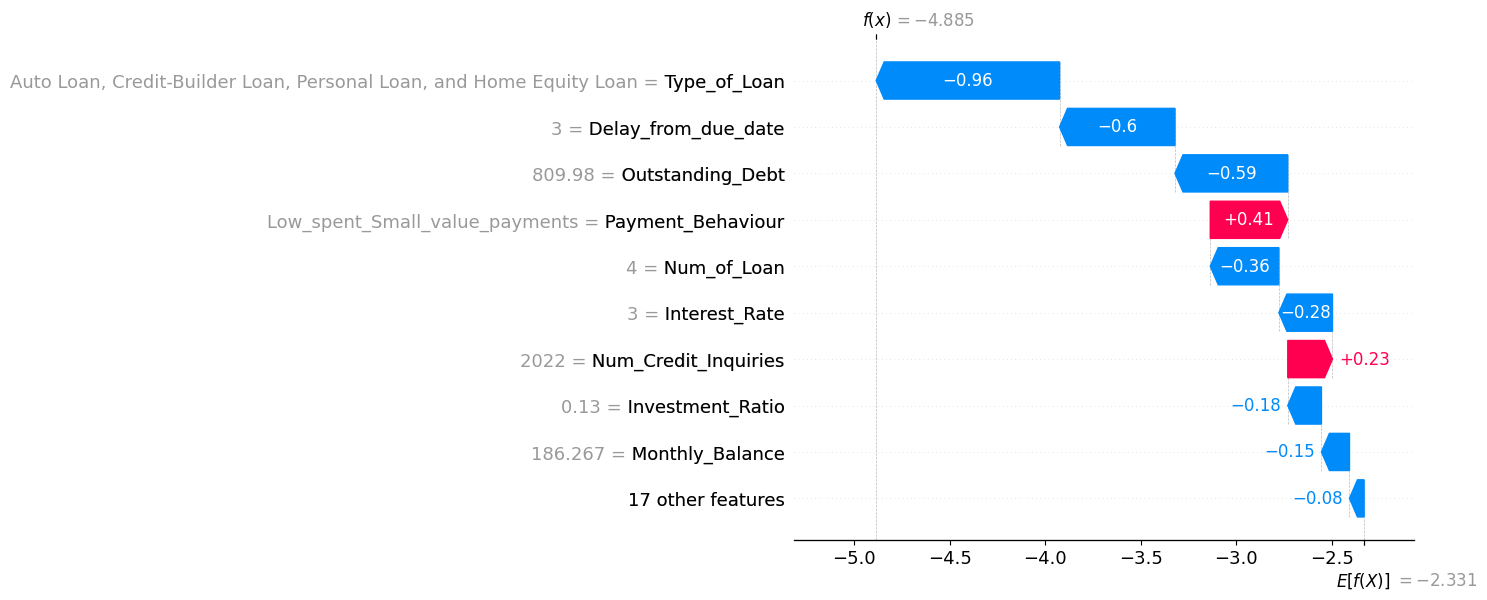


--- Explicação para classe: Standard ---


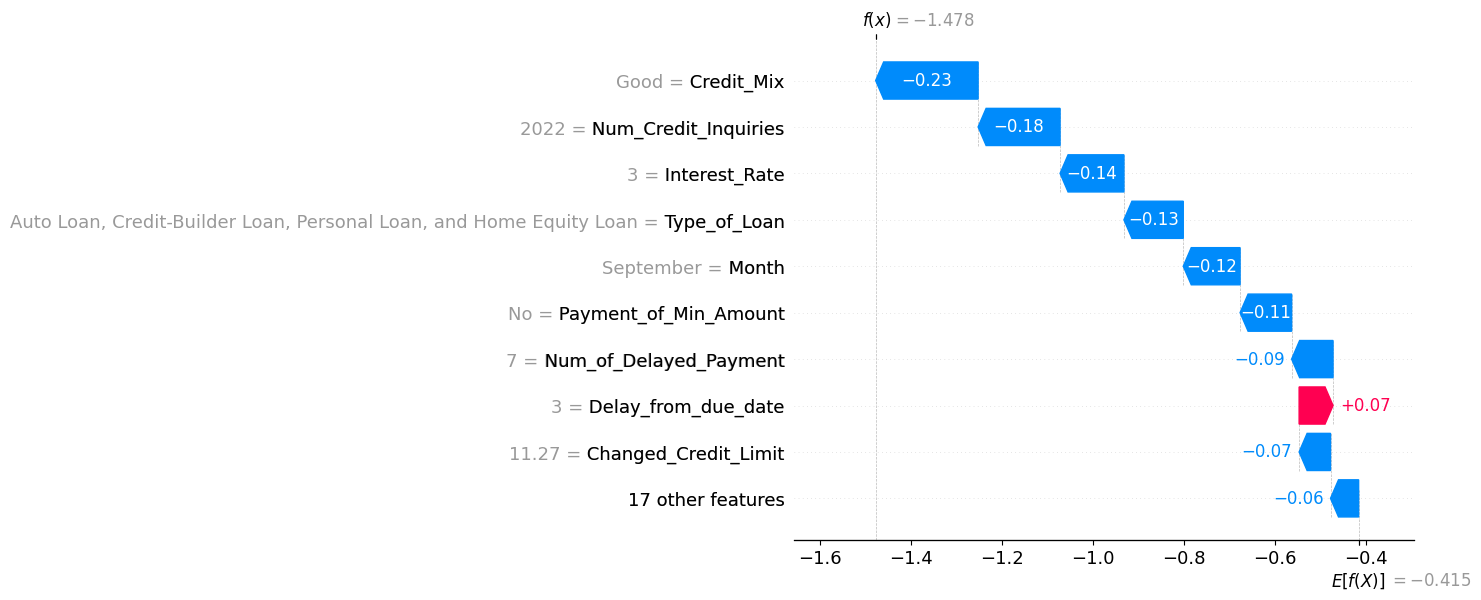

In [65]:
import shap

# ============================================================
# 1. TREINAR MODELO FINAL (todo o treino, sem CV)
# Para SHAP é melhor usar um modelo treinado em X inteiro
# ============================================================
modelo_final = lgb.LGBMClassifier(**params)
modelo_final.fit(X, y, categorical_feature=colunas_cat)

# ============================================================
# 2. CRIAR O EXPLAINER
# ============================================================
explainer = shap.TreeExplainer(modelo_final)

# ============================================================
# 3. SHAP GLOBAL — amostra de 2000 linhas
# ============================================================
X_sample = X.sample(2000, random_state=42)
shap_values = explainer(X_sample)
# shap_values.values shape: (2000, n_features, n_classes)

# Beeswarm — impacto por feature para cada classe
print(f"\n===== Impacto por feature para cada classe =====")
for i, classe in enumerate(le.classes_):
    print(f"\n=== Classe: {classe} ===")
    shap.plots.bar(shap_values[:, :, i], max_display=15)

# Bar chart — importância média global (todas as classes)
print(f"\n===== Importância média global (todas as classes) =====")
mean_abs_shap = np.abs(shap_values.values).mean(axis=0).mean(axis=1)

# Importância média por feature (bar chart)
print(f"\n=== Importância média por feature ===")
shap.summary_plot(shap_values, X_sample, plot_type='bar', class_names=le.classes_)


# ============================================================
# 4. SHAP LOCAL — explicar um cliente específico
# ============================================================
idx = 0  # índice do cliente no X_test
cliente = X_test.iloc[[idx]]

shap_values_cliente = explainer(cliente)
# shap_values_cliente.values shape: (1, n_features, n_classes)

# Classe predita pelo modelo
classe_predita = modelo_final.predict(cliente)[0]
nome_classe = le.inverse_transform([classe_predita])[0]
print(f"\nClasse predita: {nome_classe} (índice {classe_predita})")

# Waterfall plot da classe predita
shap.plots.waterfall(shap_values_cliente[0, :, classe_predita])

# ============================================================
# 5. BONUS - comparar as 3 classes para o mesmo cliente
# ============================================================
for i, classe in enumerate(le.classes_):
    print(f"\n--- Explicação para classe: {classe} ---")
    shap.plots.waterfall(shap_values_cliente[0, :, i])

-----

# 6. Relatório Final

A Data Girls Finance quer tornar sua análise de crédito mais escalável, consistente e orientada por dados. O desafio foi transformar um histórico rico de clientes, com informações financeiras, comportamento de pagamento, endividamento e perfil de crédito, em um sistema capaz de classificar o `Credit_Score` em três faixas: `Good`, `Standard` e `Poor`.

O projeto seguiu uma lógica de negócio bastante realista. Primeiro, foi necessário entender a anatomia dos dados e corrigir problemas de qualidade que inviabilizariam qualquer modelo confiável: tipos incorretos, nulos explícitos e escondidos, valores sujos e outliers improváveis. Em seguida, a análise exploratória mostrou como o portfólio está distribuído e quais sinais parecem estar mais ligados ao risco de crédito. Por fim, foram comparados dois modelos com perfis bem diferentes: um modelo linear e altamente interpretável, e um modelo baseado em árvores, mais flexível para capturar interações complexas.

O resultado central do trabalho é que o comportamento de crédito não é linear. Clientes com maior risco não são explicados por uma única variável isolada, mas pela combinação entre atraso, dívida, quantidade de consultas, utilização do crédito e tempo de histórico. Por isso, o LightGBM se destacou claramente como a melhor solução analítica do pipeline.

----

## Documentação completa do pipeline
### 1. Leitura e exploração inicial
Foram utilizadas `pandas`, `numpy`, `matplotlib` e `seaborn` para carregar, inspecionar e visualizar os dados. Essas bibliotecas são escolhas adequadas porque:
- `pandas` é a base mais usada para manipulação tabular em ciência de dados;
- `numpy` oferece operações numéricas vetorizadas e suporte eficiente a arrays;
- `matplotlib` e `seaborn` permitem construir visualizações exploratórias e comparativas com rapidez e bom controle.

A exploração inicial validou dimensões, tipos e presença de nulos, além de confirmar que o dataset de teste não possuía a coluna alvo, o que evita vazamento de informação no processo de previsão.

### 2. Limpeza e preparação dos dados
A etapa de preparação foi extensa e necessária. O notebook converteu colunas com tipos errados, como `Age`, `Outstanding_Debt`, `Annual_Income` e `Credit_History_Age`, removendo caracteres espúrios e transformando os valores em formatos numéricos utilizáveis (`astype()`, `pd.to_numeric()`).

Também foi criada uma representação numérica mais útil para o histórico de crédito, convertendo anos e meses em meses totais e anos fracionários (`str.extract()`). Isso melhora a leitura estatística e a capacidade dos modelos de usar a informação temporal do histórico.

Para outliers, o notebook tomou uma decisão orientada por negócio: não remover indiscriminadamente valores altos que podem ser reais em finanças, como renda muito elevada, mas aplicar winsorização via `clip()` em colunas claramente distorcidas, como `Num_Bank_Accounts`, `Num_Credit_Card` e `Age`. Essa foi uma boa escolha porque preserva o volume de dados e reduz a influência de registros absurdos sem apagar completamente a observação.

Nos valores ausentes, houve duas frentes:
- nulos explícitos, tratados com mediana para variáveis numéricas e moda para categóricas (`fillna()`);
- nulos escondidos e placeholders como `_______`, `_` e `__`, convertidos antes para `NaN` (`replace()`).

Essa estratégia é adequada porque a mediana é robusta a assimetria e outliers, enquanto a moda preserva a categoria mais frequente sem criar rótulos artificiais. Também verificamos ausência de duplicados com `duplicated().sum()`.

### 3. Análise exploratória
A EDA mostrou que a classe `Standard` domina a base, com `53,17%`, seguida de `Poor` com `29,00%` e `Good` com `17,83%`. Isso sugere um portfólio concentrado em clientes medianos, com uma minoria em situação realmente favorável.

Destacamos que a distribuição por ocupação é relativamente homogênea e que clientes com score `Good` tendem a ser levemente mais velhos. Também foi observado que a maior concentração de renda mensal está entre 20 e 40 anos, tipicamente entre 2 e 4 mil em média.

### 4. Modelagem preditiva
Foram comparados dois modelos.

#### Modelo 1: LightGBM
O modelo principal foi `lgb.LGBMClassifier()`, treinado com validação cruzada estratificada em 5 folds (`StratifiedKFold()`). O alvo foi codificado com `LabelEncoder()`.

O LightGBM é uma excelente escolha para esse problema, visto que lida muito bem com relações não lineares, captura interações entre variáveis automaticamente e costuma apresentar ótimo equilíbrio entre performance, velocidade e capacidade de generalização.

#### Modelo 2: Regressão Logística
Como baseline interpretável, foi usada uma pipeline com `ColumnTransformer()`, `StandardScaler()`, `OrdinalEncoder()` e `LogisticRegression()`.

Essa escolha também foi correta como comparação metodológica, porque regressão logística é um clássico de scorecard de crédito e fornece uma referência forte de interpretabilidade. Porém, por ser linear, ela tende a perder desempenho quando o problema depende de combinações complexas entre variáveis.

### 5. Avaliação dos modelos
As métricas escolhidas foram coerentes com um problema multiclasse de crédito: `accuracy_score()`, `f1_score(average='macro')`, `roc_auc_score(multi_class='ovr')`, Gini derivado do AUC, além de matriz de confusão e FNR por classe com `confusion_matrix()`.

O uso de FNR por classe foi especialmente importante, porque em crédito errar clientes `Poor` significa aprovar ou priorizar mal perfis com maior risco. Isso é mais grave do que simplesmente perder alguns pontos de acurácia.

### 6. Explicabilidade
A interpretabilidade foi trabalhada com `shap.TreeExplainer()`, usando explicabilidade global e local.

Na análise global, foram avaliados os impactos médios das features por classe em uma amostra de 2000 linhas. Na análise local, explicamos a decisão para um cliente específico  Essa combinação é uma boa escolha porque permite unir com a visão executiva do comportamento do modelo.

----

## Principais achados e insights

#### Quais variáveis podem ter maior relação com a capacidade de pagamento dos clientes?

As variáveis mais ligadas à capacidade de pagamento são: fidelidade do cliente, dívida a pagar, atraso em pagamentos, tipo de empréstimo e intensidade do endividamento mensal. A lógica de negócio é clara: histórico mais longo tende a sinalizar comportamento mais estável, enquanto dívida pendente alta, mais atrasos e mais consultas no crédito podem indicar estresse financeiro ou crédito sendo buscado com maior urgência.

#### Qual perfil de cliente possui maior probabilidade de ser classificado com score “Poor”?
O perfil mais associado a `Poor` tende a combinar sinais de fragilidade financeira: maior dívida pendente, histórico de crédito mais curto, atrasos recorrentes, mais consultas de crédito e pior composição de crédito (`Credit_Mix`). Não parece ser uma questão de ocupação isolada, pois a EDA indicou distribuição relativamente homogênea por profissão. O risco emerge mais da combinação entre comportamento financeiro e histórico de crédito do que de atributos demográficos simples.

#### Um modelo de Machine Learning consegue classificar o score de crédito com boa performance?
Sim. O LightGBM apresentou desempenho forte: `AUC-ROC = 0,9295`, `Gini = 0,8590`, `Acurácia = 0,8113` e `F1-Macro = 0,8020`. Em contraste, a regressão logística ficou muito abaixo, com `AUC-ROC = 0,7686`, `Acurácia = 0,5929` e `F1-Macro = 0,4896`.

O ponto mais crítico é o `FNR (Poor)`: o LightGBM erra cerca de `18,76%` dos clientes ruins, enquanto a regressão logística erra `56,18%`. Isso torna a RL inadequada para tomada de decisão operacional de crédito.

### Como os resultados do modelo poderiam apoiar uma equipe de crédito?
Há diversas formas de apoiar a equipe de crédito, algumas delas são:
- priorizar análises manuais em clientes com maior probabilidade de `Poor`;
- acelerar aprovações em perfis com forte sinal de `Good`, que tal uma automação baseada em ML?;
- revisar limites de clientes `Standard` com possíveis sinais de inadimplência;
- aproximar o relacionamento com clientes para prevenção de inadimplência;
- direcionar ações de educação financeira e retenção para clientes com histórico curto, alta dívida e sinais de risco crescente.

A comparação entre treino e teste previsto também sugere um ponto de atenção: o modelo estimou declínio da classe `Standard` para `50,39%` e queda de `Good` para `19%`. Isso pode indicar uma carteira nova mais conservadora, mais mediana ou um cenário de menor qualidade relativa dos clientes avaliados, visto que o Good não cresceu tanto.

### Quais cuidados éticos e de negócio devem ser considerados antes de usar o modelo em produção?
Antes de ir para produção, alguns cuidados são indispensáveis:
- validar viés indireto. Mesmo sem usar explicitamente atributos sensíveis, variáveis comportamentais podem funcionar como proxies;
- monitoramento do cenário econômico global, já que comportamento de crédito muda com contexto econômico;
- analisar custo de erro por classe, principalmente falsos negativos em `Poor` e falsos positivos em `Good`.

## Recomendações práticas
1. Adotar o LightGBM como modelo principal para a esteira analítica, mantendo a regressão logística apenas como baseline interpretável.
2. Levar para produção um pipeline formal de limpeza e padronização, porque boa parte do valor do projeto veio do tratamento rigoroso dos dados.
3. Usar os insights de SHAP para construir políticas de ação, por exemplo: revisão de limite para clientes com dívidas crescendo e muitas consultas, ou incentivo comercial para clientes com bom histórico e fidelidade longa.
4. Implementar monitoramento contínuo de métricas, especialmente `FNR` da classe `Poor`, além de distribuição das classes previstas.
5. Incluir governança ética e trilha de auditoria nas decisões apoiadas pelo modelo.

-----

## Conclusão
O projeto mostrou que é possível construir um classificador de credit score com boa performance e valor prático para negócio. O LightGBM foi a melhor escolha porque capturou padrões não lineares e entregou desempenho muito superior ao baseline linear. 

Muito mais do que prever classes, o trabalho gerou uma visão total dos clientes: quais sinais indicam maior risco, quais perfis merecem atenção e como um time de crédito pode usar esse tipo de solução para priorizar análises, reduzir perdas e apoiar decisões com mais consistência.

-----



Este notebook foi apresentado como projeto final para formação em Ciência de Dados "[Re]Start" do grupo DataGirls.